## SwiGLU Compression

The purpose of this replacement strategy is to replace original operators with swiGLU operators with variable widths based on selected importance and budget allocation strategies. A simple example given arbitrary importance vector I = [5, 2, 8, 1], blocks should have swiGLU widths assigned w = [w1,w2,w3, w4] respectively so w_i is proportiol to I[i].

The idea of this notebook compression strategy is inspired by ModeGPT budget allocation schema. We take the softmax based global average sparsity allocation/distribution and test different and more complex importance estimation inputs $s_i$

$$
\max_{\boldsymbol{\phi}}
\sum_{i=1}^{L} s_i(1-\phi_i) + \epsilon H(\boldsymbol{\phi})
$$

subject to:

$$
\frac{1}{L}\sum_{i=1}^{L}\phi_i = \phi_{\mathrm{avg}},
\qquad
0 \leq \phi_i \leq 1.
$$


then $\phi_i$ are the individual sparsities allocated for each new MLP operator, this way we can distribute global sparsity across blocks individually.

#### setup

In [1]:
from copy import deepcopy
from dataclasses import asdict
from datetime import datetime, timezone
import json
import math
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.analysis.screening import compute_bi_scores
from mlp_replacement.capture import collect_modules_io
from mlp_replacement.compression.recovery import (
    cache_teacher_logits,
    mean_cache_loss,
    recover_replacements,
)
from mlp_replacement.compression.surgery import temporary_replacements
from mlp_replacement.config import (
    CaptureConfig,
    DataConfig,
    DatasetSpec,
    ModelConfig,
    OperatorConfig,
    RecoveryConfig,
)
from mlp_replacement.data import (
    DataLoaders,
    build_data_loaders,
    contiguous_token_windows,
    load_text_dataset,
    make_token_loader,
    sample_partitioned_windows,
)
from mlp_replacement.evaluation.footprint import parameter_footprint
from mlp_replacement.evaluation.language_model import (
    evaluate_language_model,
)
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import (
    discover_mlp_blocks,
    load_model_and_tokenizer,
)
from mlp_replacement.operators import (
    GatedMLPReplacement,
    fit_operator,
    initialize_gated_mlp_from_teacher,
    swiglu_neuron_importance_scores,
)
from mlp_replacement.runlog import environment_record

In [4]:
LEGACY_EXECUTION_MODE = 'load'
RUN_LEGACY_FROM_SCRATCH = LEGACY_EXECUTION_MODE == 'run'
LEGACY_ARTIFACT_SCHEMA_VERSION = 2
LEGACY_ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-model-study'
    / 'swiglu-compression.json'
)
LEGACY_RUN_ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-model-study'
    / 'swiglu-compression-larger-budget.json'
)
legacy_artifact = (
    None
    if RUN_LEGACY_FROM_SCRATCH
    else json.loads(
        LEGACY_ARTIFACT_PATH.read_text(encoding='utf-8')
    )
)
if (
    not RUN_LEGACY_FROM_SCRATCH
    and legacy_artifact.get('schema_version')
    != LEGACY_ARTIFACT_SCHEMA_VERSION
):
    raise ValueError('Incompatible historical SwiGLU artifact')

SEED = 21
PROTECTED_PREFIX = 1
PROTECTED_SUFFIX = 1
RECOVERY_BATCHES = 64

In [5]:
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

In [6]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)

data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=RECOVERY_BATCHES,
    num_recovery_validation_batches=24,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

capture_config = CaptureConfig(
    storage_device='cpu',
    storage_dtype='float32',
)

training_config = OperatorConfig(
    kind='swiglu',
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

recovery_config = RecoveryConfig(
    enabled=True,
    epochs=1,
    learning_rate=1e-5,
    weight_decay=0.0,
    temperature=1.0,
    cache_dtype='float16',
    early_stopping_patience=None,
)

#### model and data

In [7]:
if RUN_LEGACY_FROM_SCRATCH:
    model, tokenizer = load_model_and_tokenizer(model_config)
    device = next(model.parameters()).device
else:
    model = tokenizer = device = None

In [8]:
if RUN_LEGACY_FROM_SCRATCH:
    mlp_blocks = discover_mlp_blocks(model)
    mlp_blocks_by_layer = {
        block.index: block for block in mlp_blocks
    }
    available_layers = [block.index for block in mlp_blocks]
    eligible_stop = len(available_layers) - PROTECTED_SUFFIX
    ELIGIBLE_LAYERS = available_layers[
        PROTECTED_PREFIX:eligible_stop
    ]
    PROTECTED_LAYERS = (
        available_layers[:PROTECTED_PREFIX]
        + available_layers[eligible_stop:]
    )
else:
    ELIGIBLE_LAYERS = legacy_artifact['configuration'][
        'eligible_layers'
    ]
    PROTECTED_LAYERS = legacy_artifact['configuration'][
        'protected_layers'
    ]
    available_layers = sorted(
        [*ELIGIBLE_LAYERS, *PROTECTED_LAYERS]
    )
    mlp_blocks = mlp_blocks_by_layer = None

In [9]:
loaders = (
    build_data_loaders(
        tokenizer,
        data_config,
        include_recovery=True,
    )
    if RUN_LEGACY_FROM_SCRATCH
    else None
)

#### original reference

In [10]:
if RUN_LEGACY_FROM_SCRATCH:
    dense_footprint = parameter_footprint(model)
    original_mlp_parameters = {
        layer: sum(
            parameter.numel()
            for parameter in mlp_blocks_by_layer[
                layer
            ].module.parameters()
        )
        for layer in available_layers
    }
    eligible_mlp_parameters = sum(
        original_mlp_parameters[layer]
        for layer in ELIGIBLE_LAYERS
    )
    fixed_model_parameters = (
        dense_footprint.parameters - eligible_mlp_parameters
    )
    dense_metrics = evaluate_language_model(
        model,
        loaders.model_validation,
        device,
        data_config.num_model_validation_batches,
    )
    validation_teacher_cache = cache_teacher_logits(
        model,
        loaders.model_validation,
        data_config.num_model_validation_batches,
        device,
        recovery_config.cache_dtype,
    )
    original_reference_df = pd.DataFrame([{
        'variant': 'dense_reference',
        'layers': len(available_layers),
        'eligible_layers': len(ELIGIBLE_LAYERS),
        'parameters': dense_footprint.parameters,
        'eligible_mlp_parameters': eligible_mlp_parameters,
        'fixed_model_parameters': fixed_model_parameters,
        'theoretical_weight_bytes': (
            dense_footprint.theoretical_weight_bytes
        ),
        'teacher_kl': 0.0,
        'loss': dense_metrics.loss,
        'perplexity': dense_metrics.perplexity,
        'predicted_tokens': dense_metrics.predicted_tokens,
        'batches': dense_metrics.batches,
    }])
else:
    original_reference_df = pd.DataFrame(
        legacy_artifact['results']['dense_reference']
    )
    dense_footprint = dense_metrics = None
    validation_teacher_cache = None
    original_mlp_parameters = None
    eligible_mlp_parameters = int(
        original_reference_df.iloc[0][
            'eligible_mlp_parameters'
        ]
    )
    fixed_model_parameters = int(
        original_reference_df.iloc[0]['fixed_model_parameters']
    )

dense_reference_perplexity = float(
    original_reference_df.iloc[0]['perplexity']
)
dense_model_parameters = int(
    original_reference_df.iloc[0]['parameters']
)
display(original_reference_df)

,variant,layers,eligible_layers,parameters,eligible_mlp_parameters,fixed_model_parameters,theoretical_weight_bytes,teacher_kl,loss,perplexity,predicted_tokens,batches
0,dense_reference,24,22,1711376384,1107296256,604080128,3422752768,0.0,2.669973,14.439586,6096,24


#### importance screening (s_i)

1) uniform
2) BI score
3) MLP score (residual-aware)

In [11]:
if RUN_LEGACY_FROM_SCRATCH:
    canonical_bi_result = compute_bi_scores(
        model,
        loaders.calibration,
        data_config.num_calibration_batches,
        device,
        scope='transformer_layer',
        layer_indices=ELIGIBLE_LAYERS,
    )
    residual_mlp_bi_result = compute_bi_scores(
        model,
        loaders.calibration,
        data_config.num_calibration_batches,
        device,
        scope='mlp_sublayer',
        layer_indices=ELIGIBLE_LAYERS,
    )
else:
    canonical_bi_result = residual_mlp_bi_result = None

In [12]:
importance_df = (
    pd.DataFrame({
        'layer': ELIGIBLE_LAYERS,
        'depth_fraction': [
            layer / (len(available_layers) - 1)
            for layer in ELIGIBLE_LAYERS
        ],
        'canonical_bi': [
            canonical_bi_result.scores[layer]
            for layer in ELIGIBLE_LAYERS
        ],
        'residual_aware_mlp_bi': [
            residual_mlp_bi_result.scores[layer]
            for layer in ELIGIBLE_LAYERS
        ],
    })
    if RUN_LEGACY_FROM_SCRATCH
    else pd.DataFrame(legacy_artifact['results']['importance'])
)

display(importance_df)

,layer,depth_fraction,canonical_bi,residual_aware_mlp_bi
0,1,0.043478,0.266024,0.131960
1,2,0.086957,0.102433,0.082451
2,3,0.130435,0.080121,0.066108
3,4,0.173913,0.064699,0.052083
4,5,0.217391,0.057739,0.044627
5,6,0.260870,0.054310,0.042444
6,7,0.304348,0.069185,0.057018
7,8,0.347826,0.065485,0.054795
8,9,0.391304,0.071205,0.053810
9,10,0.434783,0.065594,0.054337


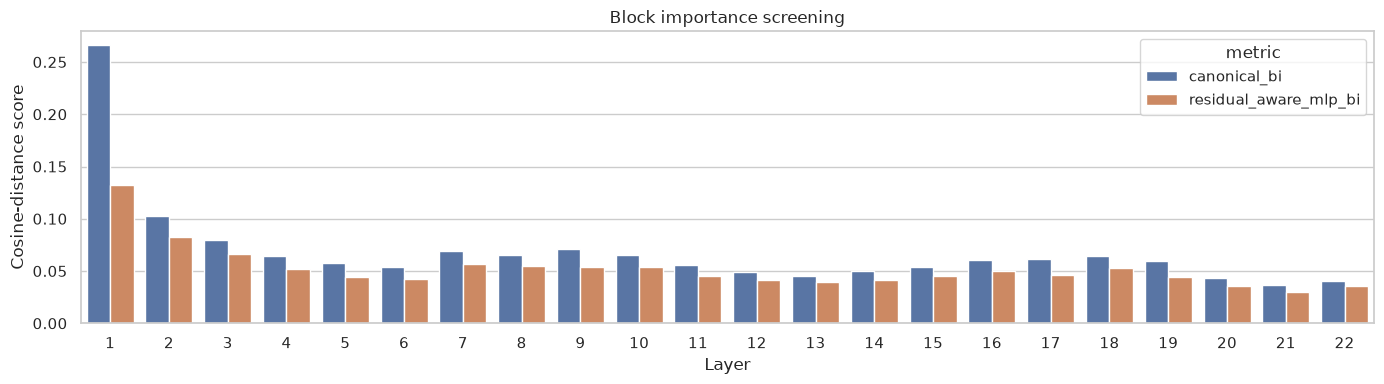

In [13]:
importance_plot_df = importance_df.melt(
    id_vars=['layer'],
    value_vars=['canonical_bi', 'residual_aware_mlp_bi'],
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(14, 4))
sns.barplot(
    data=importance_plot_df,
    x='layer',
    y='score',
    hue='metric',
)
plt.title('Block importance screening')
plt.xlabel('Layer')
plt.ylabel('Cosine-distance score')
plt.tight_layout()
plt.show()

#### global budget

In [14]:
TARGET_MLP_SPARSITY = 0.50

In [15]:
if RUN_LEGACY_FROM_SCRATCH:
    target_removed_parameters = round(
        eligible_mlp_parameters * TARGET_MLP_SPARSITY
    )
    target_retained_mlp_parameters = (
        eligible_mlp_parameters - target_removed_parameters
    )
    target_model_parameters = (
        fixed_model_parameters + target_retained_mlp_parameters
    )
    target_model_reduction = (
        1 - target_model_parameters / dense_footprint.parameters
    )
    global_budget_df = pd.DataFrame([{
        'target_scope': 'eligible_mlp',
        'target_reduction': TARGET_MLP_SPARSITY,
        'target_retention': 1 - TARGET_MLP_SPARSITY,
        'original_eligible_mlp_parameters': (
            eligible_mlp_parameters
        ),
        'target_removed_parameters': target_removed_parameters,
        'target_retained_mlp_parameters': (
            target_retained_mlp_parameters
        ),
        'fixed_model_parameters': fixed_model_parameters,
        'target_model_parameters': target_model_parameters,
        'target_model_reduction': target_model_reduction,
    }])
else:
    global_budget_df = pd.DataFrame(
        legacy_artifact['results']['global_budget']
    )
    budget_row = global_budget_df.iloc[0]
    target_removed_parameters = int(
        budget_row['target_removed_parameters']
    )
    target_retained_mlp_parameters = int(
        budget_row['target_retained_mlp_parameters']
    )
    target_model_parameters = int(
        budget_row['target_model_parameters']
    )
    target_model_reduction = float(
        budget_row['target_model_reduction']
    )

display(global_budget_df)

,target_scope,target_reduction,target_retention,original_eligible_mlp_parameters,target_removed_parameters,target_retained_mlp_parameters,fixed_model_parameters,target_model_parameters,target_model_reduction
0,eligible_mlp,0.5,0.5,1107296256,553648128,553648128,604080128,1157728256,0.32351


#### allocation strategies

In [16]:
ALLOCATION_TEMPERATURE = 1.0

allocation_importance = (
    {
        'canonical_bi': canonical_bi_result.scores,
        'residual_aware_mlp_bi': residual_mlp_bi_result.scores,
    }
    if RUN_LEGACY_FROM_SCRATCH
    else {}
)

In [17]:
def rank_normalize_scores(scores):
    values = pd.Series(scores, dtype=float)
    return (
        (values.rank(method='average') - 1) / (len(values) - 1)
    ).to_dict()


def allocate_swiglu_widths(
    policy,
    scores=None,
    target_sparsity=TARGET_MLP_SPARSITY,
):
    allocation_removed_parameters = round(
        eligible_mlp_parameters * target_sparsity
    )
    allocation_retained_parameters = (
        eligible_mlp_parameters - allocation_removed_parameters
    )
    original_parameters = {
        layer: original_mlp_parameters[layer]
        for layer in ELIGIBLE_LAYERS
    }
    normalized_scores = (
        rank_normalize_scores(scores) if scores is not None else None
    )
    removal_propensity = {
        layer: (
            math.exp(
                -normalized_scores[layer] / ALLOCATION_TEMPERATURE
            )
            if normalized_scores is not None
            else 1.0
        )
        for layer in ELIGIBLE_LAYERS
    }
    removal_denominator = sum(
        original_parameters[layer] * removal_propensity[layer]
        for layer in ELIGIBLE_LAYERS
    )

    rows = []
    for layer in ELIGIBLE_LAYERS:
        block = mlp_blocks_by_layer[layer].module
        hidden_size = block.up_proj.in_features
        original_width = block.up_proj.out_features
        parameter_step = 3 * hidden_size
        removal_share = (
            original_parameters[layer] * removal_propensity[layer]
            / removal_denominator
        )
        allocated_removal = (
            allocation_removed_parameters * removal_share
        )
        allocated_parameter_cap = (
            original_parameters[layer] - allocated_removal
        )
        continuous_width = allocated_parameter_cap / parameter_step
        rows.append({
            'policy': policy,
            'layer': layer,
            'raw_importance': (
                scores[layer] if scores is not None else None
            ),
            'normalized_importance': (
                normalized_scores[layer]
                if normalized_scores is not None
                else None
            ),
            'allocated_sparsity': (
                allocated_removal / original_parameters[layer]
            ),
            'allocated_retention': (
                allocated_parameter_cap / original_parameters[layer]
            ),
            'original_width': original_width,
            'continuous_width': continuous_width,
            'replacement_width': int(continuous_width),
            'parameter_step': parameter_step,
            'original_parameters': original_parameters[layer],
        })

    remaining_budget = allocation_retained_parameters - sum(
        row['replacement_width'] * row['parameter_step']
        for row in rows
    )
    rounding_order = sorted(
        rows,
        key=lambda row: (
            row['continuous_width'] - row['replacement_width']
        ),
        reverse=True,
    )
    for row in rounding_order:
        if row['parameter_step'] <= remaining_budget:
            row['replacement_width'] += 1
            remaining_budget -= row['parameter_step']

    for row in rows:
        row['replacement_width_ratio'] = (
            row['replacement_width'] / row['original_width']
        )
        row['replacement_parameters'] = (
            row['replacement_width'] * row['parameter_step']
        )
        row['realized_sparsity'] = (
            1
            - row['replacement_parameters'] / row['original_parameters']
        )

    return pd.DataFrame(rows).drop(
        columns=['continuous_width', 'parameter_step']
    )

In [18]:
if RUN_LEGACY_FROM_SCRATCH:
    allocation_df = pd.concat(
        [
            allocate_swiglu_widths('uniform'),
            allocate_swiglu_widths(
                'canonical_bi',
                allocation_importance['canonical_bi'],
            ),
            allocate_swiglu_widths(
                'residual_aware_mlp_bi',
                allocation_importance['residual_aware_mlp_bi'],
            ),
        ],
        ignore_index=True,
    )
    allocation_summary_df = (
        allocation_df
        .groupby('policy', sort=False, as_index=False)
        .agg(
            original_mlp_parameters=(
                'original_parameters', 'sum'
            ),
            replacement_mlp_parameters=(
                'replacement_parameters', 'sum'
            ),
            minimum_width_ratio=(
                'replacement_width_ratio', 'min'
            ),
            maximum_width_ratio=(
                'replacement_width_ratio', 'max'
            ),
        )
    )
    allocation_summary_df['mlp_sparsity'] = (
        1
        - allocation_summary_df['replacement_mlp_parameters']
        / allocation_summary_df['original_mlp_parameters']
    )
    allocation_summary_df['model_parameters'] = (
        fixed_model_parameters
        + allocation_summary_df['replacement_mlp_parameters']
    )
    allocation_summary_df['model_sparsity'] = (
        1
        - allocation_summary_df['model_parameters']
        / dense_footprint.parameters
    )
    allocation_summary_df['retained_budget_difference'] = (
        allocation_summary_df['replacement_mlp_parameters']
        - target_retained_mlp_parameters
    )
else:
    allocation_df = pd.DataFrame(
        legacy_artifact['results']['allocation']
    )
    allocation_summary_df = pd.DataFrame(
        legacy_artifact['results']['allocation_summary']
    )

allocation_width_df = (
    allocation_df
    .pivot(
        index='layer',
        columns='policy',
        values='replacement_width_ratio',
    )
    .reset_index()
)

display(allocation_summary_df)
display(allocation_width_df)

,policy,original_mlp_parameters,replacement_mlp_parameters,minimum_width_ratio,maximum_width_ratio,mlp_sparsity,model_parameters,model_sparsity,retained_budget_difference
0,uniform,1107296256,553648128,0.500000,0.500000,0.5,1157728256,0.32351,0
1,canonical_bi,1107296256,553648128,0.212036,0.710205,0.5,1157728256,0.32351,0
2,residual_aware_mlp_bi,1107296256,553648128,0.212036,0.710205,0.5,1157728256,0.32351,0


policy,layer,canonical_bi,residual_aware_mlp_bi,uniform
0,1,0.710205,0.710205,0.5
1,2,0.696045,0.696045,0.5
2,3,0.681152,0.681152,0.5
3,4,0.595459,0.575684,0.5
4,5,0.486694,0.435425,0.5
5,6,0.435425,0.407959,0.5
6,7,0.649292,0.665649,0.5
7,8,0.614258,0.649292,0.5
8,9,0.665649,0.614258,0.5
9,10,0.632202,0.632202,0.5


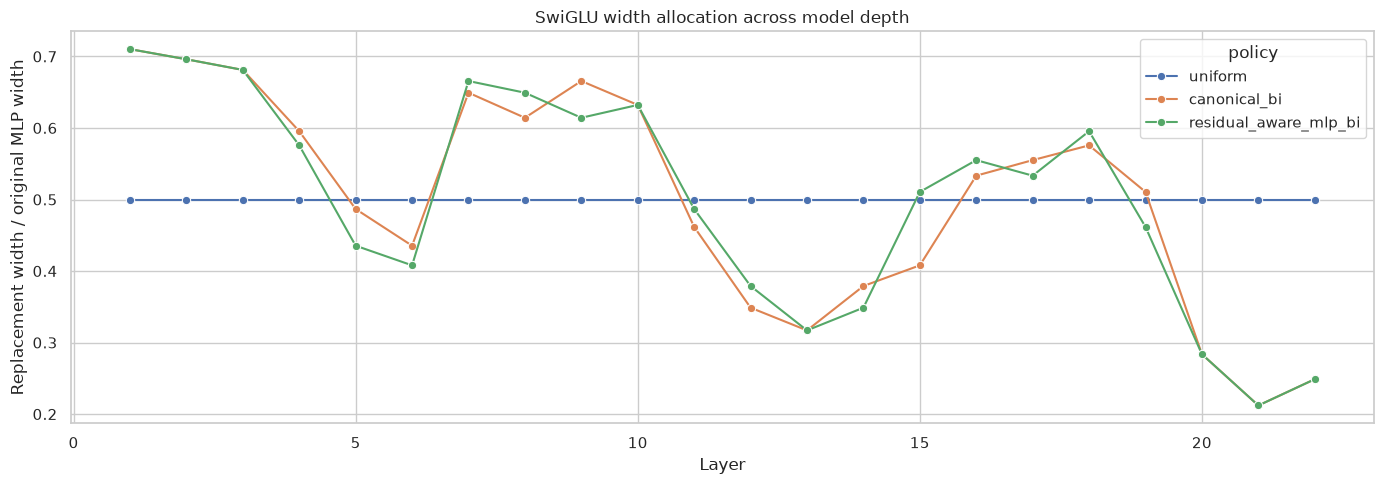

In [19]:
plt.figure(figsize=(14, 5))
sns.lineplot(
    data=allocation_df,
    x='layer',
    y='replacement_width_ratio',
    hue='policy',
    marker='o',
)
plt.title('SwiGLU width allocation across model depth')
plt.xlabel('Layer')
plt.ylabel('Replacement width / original MLP width')
plt.tight_layout()
plt.show()

#### replacement fitting

In [20]:
if RUN_LEGACY_FROM_SCRATCH:
    eligible_paths = [
        mlp_blocks_by_layer[layer].path
        for layer in ELIGIBLE_LAYERS
    ]
    training_pairs_by_path = collect_modules_io(
        model,
        eligible_paths,
        loaders.calibration,
        data_config.num_calibration_batches,
        device,
        storage_device=capture_config.storage_device,
        storage_dtype=torch.float32,
    )
    validation_pairs_by_path = collect_modules_io(
        model,
        eligible_paths,
        loaders.operator_validation,
        data_config.num_operator_validation_batches,
        device,
        storage_device=capture_config.storage_device,
        storage_dtype=torch.float32,
    )
else:
    eligible_paths = []
    training_pairs_by_path = {}
    validation_pairs_by_path = {}

In [21]:
fitted_operators = {}
fitting_rows = []
history_rows = []

for policy, policy_allocation in (
    allocation_df.groupby('policy', sort=False)
    if RUN_LEGACY_FROM_SCRATCH
    else ()
):
    fitted_operators[policy] = {}
    for allocation in policy_allocation.itertuples(index=False):
        layer = int(allocation.layer)
        block = mlp_blocks_by_layer[layer]
        training_pairs = training_pairs_by_path[block.path]
        validation_pairs = validation_pairs_by_path[block.path]
        module = GatedMLPReplacement(
            training_pairs.hidden_size,
            int(allocation.replacement_width),
        )
        fit = fit_operator(
            module,
            training_pairs,
            validation_pairs,
            training_config,
            device,
        )
        metrics = evaluate_operator(
            fit.module,
            validation_pairs,
            device,
            training_config.batch_size,
        )
        fitted_operators[policy][layer] = fit.module.to('cpu')
        fitting_rows.append({
            'policy': policy,
            'layer': layer,
            'replacement_width': int(allocation.replacement_width),
            'replacement_width_ratio': (
                allocation.replacement_width_ratio
            ),
            'replacement_parameters': (
                allocation.replacement_parameters
            ),
            'best_epoch': fit.best_epoch,
            'local_mse': metrics.mse,
            'local_relative_mse': metrics.relative_mse,
            'local_cosine': metrics.cosine_similarity,
        })
        for epoch in fit.history:
            history_rows.append({
                'policy': policy,
                'layer': layer,
                'epoch': epoch.epoch,
                'train_mse': epoch.train_mse,
                'validation_mse': epoch.validation_mse,
                'learning_rate': epoch.learning_rate,
            })

In [22]:
if RUN_LEGACY_FROM_SCRATCH:
    operator_fitting_df = pd.DataFrame(fitting_rows)
    operator_training_history_df = pd.DataFrame(history_rows)
else:
    operator_fitting_df = pd.DataFrame(
        legacy_artifact['results']['operator_fitting']
    )
    operator_training_history_df = pd.DataFrame(
        legacy_artifact['results']['operator_training_history']
    )

display(operator_fitting_df)

,policy,layer,replacement_width,replacement_width_ratio,replacement_parameters,best_epoch,local_mse,local_relative_mse,local_cosine
0,uniform,1,4096,0.500000,25165824,64,0.887763,0.019232,0.385375
1,uniform,2,4096,0.500000,25165824,44,0.152629,0.636135,0.594959
2,uniform,3,4096,0.500000,25165824,42,0.235639,0.627743,0.610577
3,uniform,4,4096,0.500000,25165824,39,0.307315,0.686855,0.552557
4,uniform,5,4096,0.500000,25165824,37,0.376950,0.742973,0.543881
...,...,...,...,...,...,...,...,...,...
61,residual_aware_mlp_bi,18,4878,0.595459,29970432,58,11.801801,0.556931,0.669185
62,residual_aware_mlp_bi,19,3782,0.461670,23236608,59,19.334716,0.578110,0.657242
63,residual_aware_mlp_bi,20,2324,0.283691,14278656,53,24.604169,0.664332,0.584314
64,residual_aware_mlp_bi,21,1737,0.212036,10672128,54,29.788836,0.675802,0.580831


#### model integration and evaluation

In [23]:
training_pairs_by_path.clear()
validation_pairs_by_path.clear()
training_pairs = None
validation_pairs = None

recovery_teacher_cache = (
    cache_teacher_logits(
        model,
        loaders.recovery,
        data_config.num_recovery_batches,
        device,
        recovery_config.cache_dtype,
    )
    if RUN_LEGACY_FROM_SCRATCH
    else None
)
recovery_validation_teacher_cache = (
    cache_teacher_logits(
        model,
        loaders.recovery_validation,
        data_config.num_recovery_validation_batches,
        device,
        recovery_config.cache_dtype,
    )
    if RUN_LEGACY_FROM_SCRATCH
    else None
)

In [24]:
evaluation_rows = []
recovery_rows = []

for policy in (
    allocation_df['policy'].drop_duplicates()
    if RUN_LEGACY_FROM_SCRATCH
    else ()
):
    replacements = {
        layer: deepcopy(fitted_operators[policy][layer])
        for layer in ELIGIBLE_LAYERS
    }
    with temporary_replacements(model, replacements) as manifest:
        target_paths = [record.path for record in manifest.records]
        footprint = parameter_footprint(model)
        pre_metrics = evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )
        pre_kl = mean_cache_loss(
            model,
            validation_teacher_cache,
            recovery_config.temperature,
            device,
        )
        evaluation_rows.append({
            'policy': policy,
            'phase': 'pre_recovery',
            'parameters': footprint.parameters,
            'model_sparsity': (
                1 - footprint.parameters / dense_footprint.parameters
            ),
            'theoretical_weight_bytes': (
                footprint.theoretical_weight_bytes
            ),
            'teacher_kl': pre_kl,
            'loss': pre_metrics.loss,
            'loss_delta': pre_metrics.loss - dense_metrics.loss,
            'perplexity': pre_metrics.perplexity,
            'perplexity_delta': (
                pre_metrics.perplexity - dense_metrics.perplexity
            ),
        })

        recovery = recover_replacements(
            model,
            recovery_teacher_cache,
            recovery_validation_teacher_cache,
            target_paths,
            recovery_config,
            device,
        )
        post_metrics = evaluate_language_model(
            model,
            loaders.model_validation,
            device,
            data_config.num_model_validation_batches,
        )
        post_kl = mean_cache_loss(
            model,
            validation_teacher_cache,
            recovery_config.temperature,
            device,
        )
        evaluation_rows.append({
            'policy': policy,
            'phase': 'post_recovery',
            'parameters': footprint.parameters,
            'model_sparsity': (
                1 - footprint.parameters / dense_footprint.parameters
            ),
            'theoretical_weight_bytes': (
                footprint.theoretical_weight_bytes
            ),
            'teacher_kl': post_kl,
            'loss': post_metrics.loss,
            'loss_delta': post_metrics.loss - dense_metrics.loss,
            'perplexity': post_metrics.perplexity,
            'perplexity_delta': (
                post_metrics.perplexity - dense_metrics.perplexity
            ),
        })

        for epoch in recovery.history:
            recovery_rows.append({
                'policy': policy,
                'epoch': epoch.epoch,
                'train_kl': epoch.train_kl,
                'validation_kl': epoch.validation_kl,
                'best_epoch': recovery.best_epoch,
            })

    for replacement in replacements.values():
        replacement.to('cpu')
    del replacements
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [25]:
if RUN_LEGACY_FROM_SCRATCH:
    model_evaluation_df = pd.DataFrame(evaluation_rows)
    recovery_history_df = pd.DataFrame(recovery_rows)
else:
    model_evaluation_df = pd.DataFrame(
        legacy_artifact['results']['model_evaluation']
    )
    recovery_history_df = pd.DataFrame(
        legacy_artifact['results']['recovery_history']
    )

display(model_evaluation_df)
display(recovery_history_df)

,policy,phase,parameters,model_sparsity,theoretical_weight_bytes,teacher_kl,loss,loss_delta,perplexity,perplexity_delta
0,uniform,pre_recovery,1157728256,0.32351,2315456512,21.954329,24.467408,21.797434,4.227272e+10,4.227272e+10
1,uniform,post_recovery,1157728256,0.32351,2315456512,8.083099,10.736900,8.066926,4.602314e+04,4.600870e+04
2,canonical_bi,pre_recovery,1157728256,0.32351,2315456512,21.573125,24.098206,21.428232,2.922253e+10,2.922253e+10
3,canonical_bi,post_recovery,1157728256,0.32351,2315456512,8.306232,10.943780,8.273807,5.660092e+04,5.658648e+04
4,residual_aware_mlp_bi,pre_recovery,1157728256,0.32351,2315456512,21.248151,23.771789,21.101816,2.108419e+10,2.108419e+10
5,residual_aware_mlp_bi,post_recovery,1157728256,0.32351,2315456512,11.065767,13.746217,11.076244,9.330532e+05,9.330387e+05


,policy,epoch,train_kl,validation_kl,best_epoch
0,uniform,1,12.931582,7.584429,1
1,canonical_bi,1,12.853028,7.694560,1
2,residual_aware_mlp_bi,1,15.970139,10.686817,1


#### result comparison

In [26]:
local_summary_df = (
    operator_fitting_df
    .groupby('policy', sort=False, as_index=False)
    .agg(
        mean_local_relative_mse=('local_relative_mse', 'mean'),
        mean_local_cosine=('local_cosine', 'mean'),
    )
)
pre_recovery_df = (
    model_evaluation_df
    .query("phase == 'pre_recovery'")
    [[
        'policy', 'teacher_kl', 'loss', 'loss_delta',
        'perplexity', 'perplexity_delta',
    ]]
    .rename(columns={
        'teacher_kl': 'pre_recovery_kl',
        'loss': 'pre_recovery_loss',
        'loss_delta': 'pre_recovery_loss_delta',
        'perplexity': 'pre_recovery_perplexity',
        'perplexity_delta': 'pre_recovery_perplexity_delta',
    })
)
post_recovery_df = (
    model_evaluation_df
    .query("phase == 'post_recovery'")
    [[
        'policy', 'teacher_kl', 'loss', 'loss_delta',
        'perplexity', 'perplexity_delta',
    ]]
    .rename(columns={
        'teacher_kl': 'post_recovery_kl',
        'loss': 'post_recovery_loss',
        'loss_delta': 'post_recovery_loss_delta',
        'perplexity': 'post_recovery_perplexity',
        'perplexity_delta': 'post_recovery_perplexity_delta',
    })
)

comparison_df = (
    allocation_summary_df
    .merge(local_summary_df, on='policy', validate='one_to_one')
    .merge(pre_recovery_df, on='policy', validate='one_to_one')
    .merge(post_recovery_df, on='policy', validate='one_to_one')
)
comparison_df['kl_reduction'] = (
    comparison_df['pre_recovery_kl']
    - comparison_df['post_recovery_kl']
)
comparison_df['perplexity_reduction'] = (
    comparison_df['pre_recovery_perplexity']
    - comparison_df['post_recovery_perplexity']
)

display(comparison_df)

,policy,original_mlp_parameters,replacement_mlp_parameters,minimum_width_ratio,maximum_width_ratio,mlp_sparsity,model_parameters,model_sparsity,retained_budget_difference,mean_local_relative_mse,...,pre_recovery_loss_delta,pre_recovery_perplexity,pre_recovery_perplexity_delta,post_recovery_kl,post_recovery_loss,post_recovery_loss_delta,post_recovery_perplexity,post_recovery_perplexity_delta,kl_reduction,perplexity_reduction
0,uniform,1107296256,553648128,0.500000,0.500000,0.5,1157728256,0.32351,0,0.551668,...,21.797434,4.227272e+10,4.227272e+10,8.083099,10.736900,8.066926,46023.139826,46008.700240,13.871230,4.227267e+10
1,canonical_bi,1107296256,553648128,0.212036,0.710205,0.5,1157728256,0.32351,0,0.553444,...,21.428232,2.922253e+10,2.922253e+10,8.306232,10.943780,8.273807,56600.916322,56586.476737,13.266893,2.922247e+10
2,residual_aware_mlp_bi,1107296256,553648128,0.212036,0.710205,0.5,1157728256,0.32351,0,0.553415,...,21.101816,2.108419e+10,2.108419e+10,11.065767,13.746217,11.076244,933053.166192,933038.726606,10.182384,2.108326e+10


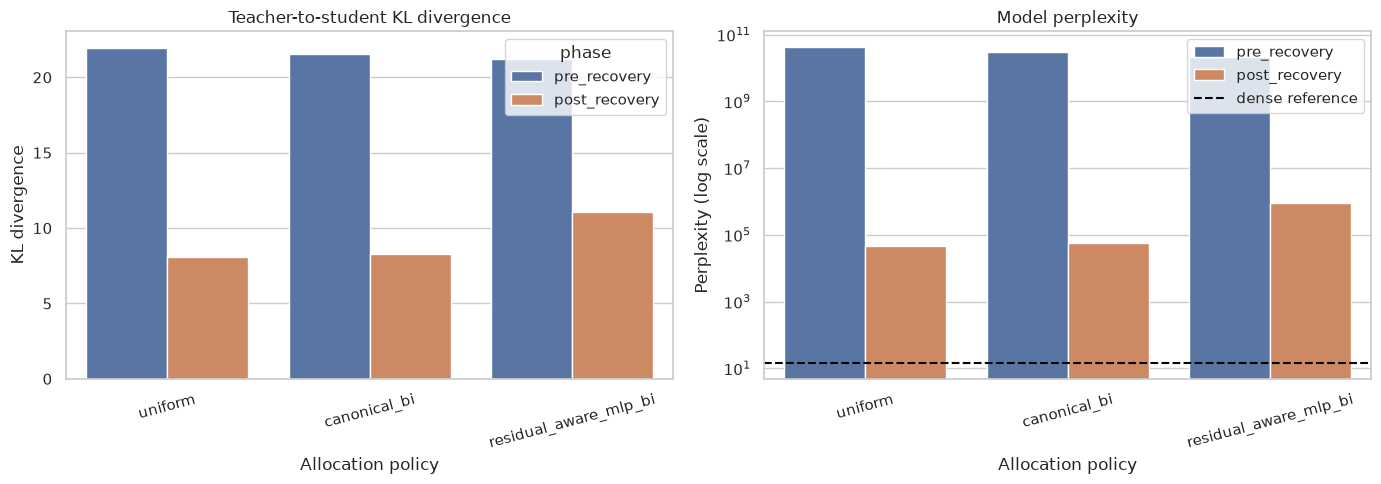

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=model_evaluation_df,
    x='policy',
    y='teacher_kl',
    hue='phase',
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title('Teacher-to-student KL divergence')
axes[0].set_xlabel('Allocation policy')
axes[0].set_ylabel('KL divergence')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(
    data=model_evaluation_df,
    x='policy',
    y='perplexity',
    hue='phase',
    errorbar=None,
    ax=axes[1],
)
axes[1].axhline(
    dense_reference_perplexity,
    color='black',
    linestyle='--',
    label='dense reference',
)
axes[1].set_yscale('log')
axes[1].set_title('Model perplexity')
axes[1].set_xlabel('Allocation policy')
axes[1].set_ylabel('Perplexity (log scale)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

#### different sparsity ratios

testing 20%, 30%, 40%, 50% comparison

In [28]:
SPARSITY_RATIOS = (0.20, 0.30, 0.40, 0.50)
SPARSITY_POLICIES = (
    'uniform',
    'canonical_bi',
    'residual_aware_mlp_bi',
)

fitted_operators.clear()
fit = None
module = None
replacement = None

sweep_training_pairs_by_path = (
    collect_modules_io(
        model,
        eligible_paths,
        loaders.calibration,
        data_config.num_calibration_batches,
        device,
        storage_device=capture_config.storage_device,
        storage_dtype=torch.float32,
    )
    if RUN_LEGACY_FROM_SCRATCH
    else {}
)
sweep_validation_pairs_by_path = (
    collect_modules_io(
        model,
        eligible_paths,
        loaders.operator_validation,
        data_config.num_operator_validation_batches,
        device,
        storage_device=capture_config.storage_device,
        storage_dtype=torch.float32,
    )
    if RUN_LEGACY_FROM_SCRATCH
    else {}
)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [29]:
sweep_allocation_frames = []
sweep_fitting_rows = []
sweep_history_rows = []
sweep_evaluation_rows = []
sweep_recovery_rows = []

if not RUN_LEGACY_FROM_SCRATCH:
    sweep_allocation_frames = [pd.DataFrame(
        legacy_artifact['results']['sparsity_sweep_allocation']
    )]
    sweep_fitting_rows = legacy_artifact['results'][
        'sparsity_sweep_operator_fitting'
    ]
    sweep_history_rows = legacy_artifact['results'][
        'sparsity_sweep_operator_training_history'
    ]
    sweep_evaluation_rows = legacy_artifact['results'][
        'sparsity_sweep_model_evaluation'
    ]
    sweep_recovery_rows = legacy_artifact['results'][
        'sparsity_sweep_recovery_history'
    ]

for target_sparsity in (
    SPARSITY_RATIOS if RUN_LEGACY_FROM_SCRATCH else ()
):
    ratio_allocation = pd.concat(
        [
            allocate_swiglu_widths(
                policy,
                allocation_importance.get(policy),
                target_sparsity,
            )
            for policy in SPARSITY_POLICIES
        ],
        ignore_index=True,
    )
    ratio_allocation.insert(
        0, 'target_mlp_sparsity', target_sparsity
    )
    sweep_allocation_frames.append(ratio_allocation)

    for policy in SPARSITY_POLICIES:
        print(f'Running {target_sparsity:.0%} | {policy}')
        policy_allocation = ratio_allocation.query(
            'policy == @policy'
        )
        replacements = {}

        for allocation in policy_allocation.itertuples(index=False):
            layer = int(allocation.layer)
            block = mlp_blocks_by_layer[layer]
            training_pairs = sweep_training_pairs_by_path[block.path]
            validation_pairs = (
                sweep_validation_pairs_by_path[block.path]
            )
            module = GatedMLPReplacement(
                training_pairs.hidden_size,
                int(allocation.replacement_width),
            )
            fit = fit_operator(
                module,
                training_pairs,
                validation_pairs,
                training_config,
                device,
            )
            metrics = evaluate_operator(
                fit.module,
                validation_pairs,
                device,
                training_config.batch_size,
            )
            replacements[layer] = fit.module.to('cpu')
            sweep_fitting_rows.append({
                'target_mlp_sparsity': target_sparsity,
                'policy': policy,
                'layer': layer,
                'replacement_width': (
                    int(allocation.replacement_width)
                ),
                'replacement_width_ratio': (
                    allocation.replacement_width_ratio
                ),
                'replacement_parameters': (
                    allocation.replacement_parameters
                ),
                'best_epoch': fit.best_epoch,
                'local_mse': metrics.mse,
                'local_relative_mse': metrics.relative_mse,
                'local_cosine': metrics.cosine_similarity,
            })
            for epoch in fit.history:
                sweep_history_rows.append({
                    'target_mlp_sparsity': target_sparsity,
                    'policy': policy,
                    'layer': layer,
                    'epoch': epoch.epoch,
                    'train_mse': epoch.train_mse,
                    'validation_mse': epoch.validation_mse,
                    'learning_rate': epoch.learning_rate,
                })

        realized_mlp_sparsity = (
            1
            - policy_allocation['replacement_parameters'].sum()
            / policy_allocation['original_parameters'].sum()
        )
        with temporary_replacements(model, replacements) as manifest:
            target_paths = [
                record.path for record in manifest.records
            ]
            footprint = parameter_footprint(model)
            pre_metrics = evaluate_language_model(
                model,
                loaders.model_validation,
                device,
                data_config.num_model_validation_batches,
            )
            pre_kl = mean_cache_loss(
                model,
                validation_teacher_cache,
                recovery_config.temperature,
                device,
            )
            sweep_evaluation_rows.append({
                'target_mlp_sparsity': target_sparsity,
                'realized_mlp_sparsity': realized_mlp_sparsity,
                'policy': policy,
                'phase': 'pre_recovery',
                'parameters': footprint.parameters,
                'model_sparsity': (
                    1
                    - footprint.parameters
                    / dense_footprint.parameters
                ),
                'theoretical_weight_bytes': (
                    footprint.theoretical_weight_bytes
                ),
                'teacher_kl': pre_kl,
                'loss': pre_metrics.loss,
                'loss_delta': (
                    pre_metrics.loss - dense_metrics.loss
                ),
                'perplexity': pre_metrics.perplexity,
                'perplexity_delta': (
                    pre_metrics.perplexity - dense_metrics.perplexity
                ),
            })

            recovery = recover_replacements(
                model,
                recovery_teacher_cache,
                recovery_validation_teacher_cache,
                target_paths,
                recovery_config,
                device,
            )
            post_metrics = evaluate_language_model(
                model,
                loaders.model_validation,
                device,
                data_config.num_model_validation_batches,
            )
            post_kl = mean_cache_loss(
                model,
                validation_teacher_cache,
                recovery_config.temperature,
                device,
            )
            sweep_evaluation_rows.append({
                'target_mlp_sparsity': target_sparsity,
                'realized_mlp_sparsity': realized_mlp_sparsity,
                'policy': policy,
                'phase': 'post_recovery',
                'parameters': footprint.parameters,
                'model_sparsity': (
                    1
                    - footprint.parameters
                    / dense_footprint.parameters
                ),
                'theoretical_weight_bytes': (
                    footprint.theoretical_weight_bytes
                ),
                'teacher_kl': post_kl,
                'loss': post_metrics.loss,
                'loss_delta': (
                    post_metrics.loss - dense_metrics.loss
                ),
                'perplexity': post_metrics.perplexity,
                'perplexity_delta': (
                    post_metrics.perplexity - dense_metrics.perplexity
                ),
            })

            for epoch in recovery.history:
                sweep_recovery_rows.append({
                    'target_mlp_sparsity': target_sparsity,
                    'policy': policy,
                    'epoch': epoch.epoch,
                    'train_kl': epoch.train_kl,
                    'validation_kl': epoch.validation_kl,
                    'best_epoch': recovery.best_epoch,
                })

        for replacement in replacements.values():
            replacement.to('cpu')
        del replacements
        fit = None
        module = None
        metrics = None
        recovery = None
        replacement = None
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

sweep_training_pairs_by_path.clear()
sweep_validation_pairs_by_path.clear()
training_pairs = None
validation_pairs = None
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [30]:
sparsity_sweep_allocation_df = pd.concat(
    sweep_allocation_frames, ignore_index=True
)
sparsity_sweep_fitting_df = pd.DataFrame(sweep_fitting_rows)
sparsity_sweep_training_history_df = pd.DataFrame(
    sweep_history_rows
)
sparsity_sweep_evaluation_df = pd.DataFrame(
    sweep_evaluation_rows
)
sparsity_sweep_recovery_history_df = pd.DataFrame(
    sweep_recovery_rows
)

sparsity_sweep_allocation_summary_df = (
    sparsity_sweep_allocation_df
    .groupby(
        ['target_mlp_sparsity', 'policy'],
        sort=False,
        as_index=False,
    )
    .agg(
        original_mlp_parameters=('original_parameters', 'sum'),
        replacement_mlp_parameters=(
            'replacement_parameters', 'sum'
        ),
        minimum_width_ratio=('replacement_width_ratio', 'min'),
        maximum_width_ratio=('replacement_width_ratio', 'max'),
    )
)
sparsity_sweep_allocation_summary_df['realized_mlp_sparsity'] = (
    1
    - sparsity_sweep_allocation_summary_df[
        'replacement_mlp_parameters'
    ]
    / sparsity_sweep_allocation_summary_df[
        'original_mlp_parameters'
    ]
)
sparsity_sweep_allocation_summary_df['model_parameters'] = (
    fixed_model_parameters
    + sparsity_sweep_allocation_summary_df[
        'replacement_mlp_parameters'
    ]
)
sparsity_sweep_allocation_summary_df['model_sparsity'] = (
    1
    - sparsity_sweep_allocation_summary_df['model_parameters']
    / dense_model_parameters
)

sweep_local_summary_df = (
    sparsity_sweep_fitting_df
    .groupby(
        ['target_mlp_sparsity', 'policy'],
        sort=False,
        as_index=False,
    )
    .agg(
        mean_local_relative_mse=('local_relative_mse', 'mean'),
        mean_local_cosine=('local_cosine', 'mean'),
    )
)
sweep_pre_recovery_df = (
    sparsity_sweep_evaluation_df
    .query("phase == 'pre_recovery'")
    [[
        'target_mlp_sparsity', 'policy', 'teacher_kl',
        'loss', 'loss_delta', 'perplexity',
        'perplexity_delta',
    ]]
    .rename(columns={
        'teacher_kl': 'pre_recovery_kl',
        'loss': 'pre_recovery_loss',
        'loss_delta': 'pre_recovery_loss_delta',
        'perplexity': 'pre_recovery_perplexity',
        'perplexity_delta': 'pre_recovery_perplexity_delta',
    })
)
sweep_post_recovery_df = (
    sparsity_sweep_evaluation_df
    .query("phase == 'post_recovery'")
    [[
        'target_mlp_sparsity', 'policy', 'teacher_kl',
        'loss', 'loss_delta', 'perplexity',
        'perplexity_delta',
    ]]
    .rename(columns={
        'teacher_kl': 'post_recovery_kl',
        'loss': 'post_recovery_loss',
        'loss_delta': 'post_recovery_loss_delta',
        'perplexity': 'post_recovery_perplexity',
        'perplexity_delta': 'post_recovery_perplexity_delta',
    })
)
sparsity_sweep_comparison_df = (
    sparsity_sweep_allocation_summary_df
    .merge(
        sweep_local_summary_df,
        on=['target_mlp_sparsity', 'policy'],
    )
    .merge(
        sweep_pre_recovery_df,
        on=['target_mlp_sparsity', 'policy'],
    )
    .merge(
        sweep_post_recovery_df,
        on=['target_mlp_sparsity', 'policy'],
    )
)
sparsity_sweep_comparison_df['kl_reduction'] = (
    sparsity_sweep_comparison_df['pre_recovery_kl']
    - sparsity_sweep_comparison_df['post_recovery_kl']
)
sparsity_sweep_comparison_df['perplexity_reduction'] = (
    sparsity_sweep_comparison_df['pre_recovery_perplexity']
    - sparsity_sweep_comparison_df['post_recovery_perplexity']
)

display(sparsity_sweep_allocation_summary_df)
display(sparsity_sweep_comparison_df)

,target_mlp_sparsity,policy,original_mlp_parameters,replacement_mlp_parameters,minimum_width_ratio,maximum_width_ratio,realized_mlp_sparsity,model_parameters,model_sparsity
0,0.2,uniform,1107296256,885835776,0.799927,0.800049,0.200001,1489915904,0.129405
1,0.2,canonical_bi,1107296256,885835776,0.684814,0.884033,0.200001,1489915904,0.129405
2,0.2,residual_aware_mlp_bi,1107296256,885835776,0.684814,0.884033,0.200001,1489915904,0.129405
3,0.3,uniform,1107296256,775102464,0.699951,0.700073,0.300004,1379182592,0.194109
4,0.3,canonical_bi,1107296256,775102464,0.527222,0.826050,0.300004,1379182592,0.194109
5,0.3,residual_aware_mlp_bi,1107296256,775102464,0.527222,0.826050,0.300004,1379182592,0.194109
6,0.4,uniform,1107296256,664375296,0.599976,0.600098,0.400002,1268455424,0.258810
7,0.4,canonical_bi,1107296256,664375296,0.369629,0.768066,0.400002,1268455424,0.258810
8,0.4,residual_aware_mlp_bi,1107296256,664375296,0.369629,0.768066,0.400002,1268455424,0.258810
9,0.5,uniform,1107296256,553648128,0.500000,0.500000,0.500000,1157728256,0.323510


,target_mlp_sparsity,policy,original_mlp_parameters,replacement_mlp_parameters,minimum_width_ratio,maximum_width_ratio,realized_mlp_sparsity,model_parameters,model_sparsity,mean_local_relative_mse,...,pre_recovery_loss_delta,pre_recovery_perplexity,pre_recovery_perplexity_delta,post_recovery_kl,post_recovery_loss,post_recovery_loss_delta,post_recovery_perplexity,post_recovery_perplexity_delta,kl_reduction,perplexity_reduction
0,0.2,uniform,1107296256,885835776,0.799927,0.800049,0.200001,1489915904,0.129405,0.536538,...,20.823936,1.596892e+10,1.596892e+10,7.944841,10.619179,7.949205,40911.995672,40897.556087,13.049160,1.596887e+10
1,0.2,canonical_bi,1107296256,885835776,0.684814,0.884033,0.200001,1489915904,0.129405,0.536493,...,21.032547,1.967314e+10,1.967314e+10,7.909279,10.607106,7.937133,40421.064494,40406.624909,13.274328,1.967310e+10
2,0.2,residual_aware_mlp_bi,1107296256,885835776,0.684814,0.884033,0.200001,1489915904,0.129405,0.536551,...,21.018247,1.939383e+10,1.939383e+10,7.789714,10.498562,7.828588,36263.313766,36248.874180,13.386680,1.939379e+10
3,0.3,uniform,1107296256,775102464,0.699951,0.700073,0.300004,1379182592,0.194109,0.540592,...,21.299263,2.568663e+10,2.568663e+10,7.989240,10.645559,7.975585,42005.613999,41991.174414,13.464640,2.568659e+10
4,0.3,canonical_bi,1107296256,775102464,0.527222,0.826050,0.300004,1379182592,0.194109,0.540751,...,20.681954,1.385522e+10,1.385522e+10,8.110575,10.762107,8.092134,47198.031663,47183.592078,12.730676,1.385517e+10
5,0.3,residual_aware_mlp_bi,1107296256,775102464,0.527222,0.826050,0.300004,1379182592,0.194109,0.540858,...,20.983393,1.872951e+10,1.872951e+10,8.207595,10.858725,8.188751,51985.745730,51971.306145,12.938725,1.872945e+10
6,0.4,uniform,1107296256,664375296,0.599976,0.600098,0.400002,1268455424,0.258810,0.545588,...,20.530922,1.191299e+10,1.191299e+10,7.884138,10.568701,7.898728,38898.110517,38883.670932,12.789787,1.191295e+10
7,0.4,canonical_bi,1107296256,664375296,0.369629,0.768066,0.400002,1268455424,0.258810,0.546237,...,20.858587,1.653194e+10,1.653194e+10,8.299540,10.934530,8.264556,56079.718509,56065.278924,12.703925,1.653188e+10
8,0.4,residual_aware_mlp_bi,1107296256,664375296,0.369629,0.768066,0.400002,1268455424,0.258810,0.546171,...,21.261346,2.473091e+10,2.473091e+10,8.302755,10.940874,8.270900,56436.626580,56422.186994,13.094543,2.473085e+10
9,0.5,uniform,1107296256,553648128,0.500000,0.500000,0.500000,1157728256,0.323510,0.551702,...,21.548330,3.295152e+10,3.295152e+10,8.155310,10.795753,8.125780,48813.050208,48798.610622,13.558644,3.295147e+10


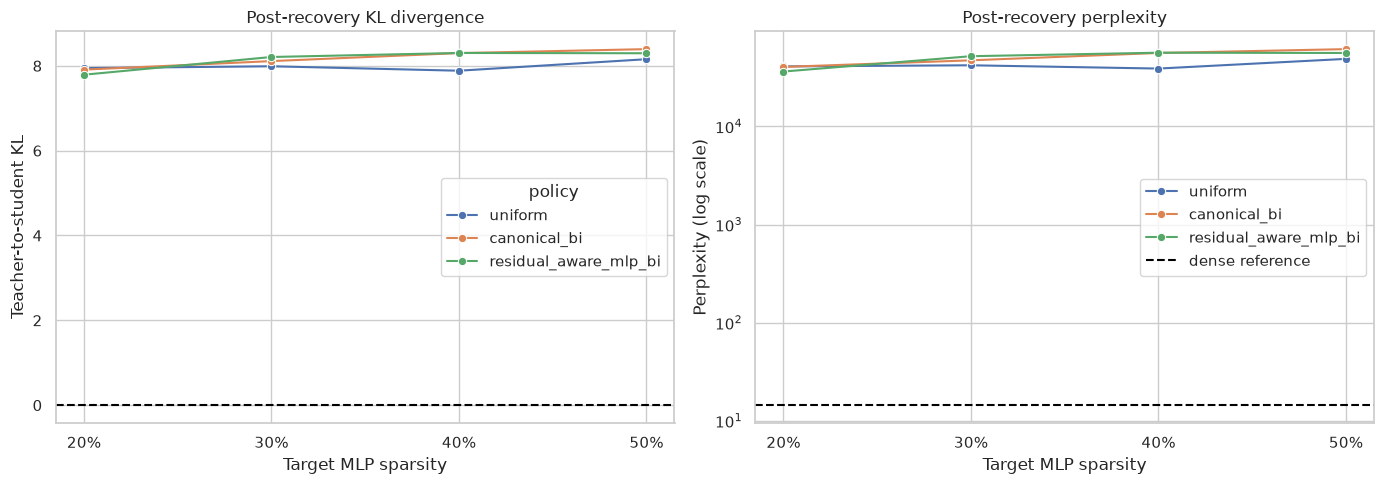

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=sweep_post_recovery_df,
    x='target_mlp_sparsity',
    y='post_recovery_kl',
    hue='policy',
    marker='o',
    ax=axes[0],
)
axes[0].axhline(0.0, color='black', linestyle='--')
axes[0].set_title('Post-recovery KL divergence')
axes[0].set_xlabel('Target MLP sparsity')
axes[0].set_ylabel('Teacher-to-student KL')
axes[0].set_xticks(
    SPARSITY_RATIOS,
    [f'{ratio:.0%}' for ratio in SPARSITY_RATIOS],
)

sns.lineplot(
    data=sweep_post_recovery_df,
    x='target_mlp_sparsity',
    y='post_recovery_perplexity',
    hue='policy',
    marker='o',
    ax=axes[1],
)
axes[1].axhline(
    dense_reference_perplexity,
    color='black',
    linestyle='--',
    label='dense reference',
)
axes[1].set_yscale('log')
axes[1].set_title('Post-recovery perplexity')
axes[1].set_xlabel('Target MLP sparsity')
axes[1].set_ylabel('Perplexity (log scale)')
axes[1].set_xticks(
    SPARSITY_RATIOS,
    [f'{ratio:.0%}' for ratio in SPARSITY_RATIOS],
)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Full capacity distillation

This part uses much larger calibration and retraining budgets in order to better capture effects of distillation.

#### artifact saving

In [32]:
def json_records(frame):
    return json.loads(
        frame.to_json(orient='records', double_precision=15)
    )


ARTIFACT_PATH = LEGACY_RUN_ARTIFACT_PATH
artifact = {
    'schema_version': 2,
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'configuration': {
        'model': {
            **asdict(model_config),
            'resolved_revision': (
                getattr(model.config, '_commit_hash', None)
                if RUN_LEGACY_FROM_SCRATCH
                else legacy_artifact['configuration'][
                    'model'
                ].get('resolved_revision')
            ),
        },
        'data': asdict(data_config),
        'capture': asdict(capture_config),
        'operator_training': asdict(training_config),
        'recovery': {
            **asdict(recovery_config),
            'trainable_scope': 'replacement_only',
        },
        'target_mlp_sparsity': TARGET_MLP_SPARSITY,
        'sparsity_sweep_ratios': list(SPARSITY_RATIOS),
        'sparsity_sweep_policies': list(SPARSITY_POLICIES),
        'allocation_temperature': ALLOCATION_TEMPERATURE,
        'eligible_layers': list(ELIGIBLE_LAYERS),
        'protected_layers': list(PROTECTED_LAYERS),
    },
    'results': {
        'dense_reference': json_records(original_reference_df),
        'importance': json_records(importance_df),
        'global_budget': json_records(global_budget_df),
        'allocation': json_records(allocation_df),
        'allocation_summary': json_records(
            allocation_summary_df
        ),
        'operator_fitting': json_records(operator_fitting_df),
        'operator_training_history': json_records(
            operator_training_history_df
        ),
        'model_evaluation': json_records(model_evaluation_df),
        'recovery_history': json_records(recovery_history_df),
        'comparison': json_records(comparison_df),
        'sparsity_sweep_allocation': json_records(
            sparsity_sweep_allocation_df
        ),
        'sparsity_sweep_allocation_summary': json_records(
            sparsity_sweep_allocation_summary_df
        ),
        'sparsity_sweep_operator_fitting': json_records(
            sparsity_sweep_fitting_df
        ),
        'sparsity_sweep_operator_training_history': json_records(
            sparsity_sweep_training_history_df
        ),
        'sparsity_sweep_model_evaluation': json_records(
            sparsity_sweep_evaluation_df
        ),
        'sparsity_sweep_recovery_history': json_records(
            sparsity_sweep_recovery_history_df
        ),
        'sparsity_sweep_comparison': json_records(
            sparsity_sweep_comparison_df
        ),
    },
}

if RUN_LEGACY_FROM_SCRATCH:
    ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
    ARTIFACT_PATH.write_text(
        json.dumps(artifact, indent=2, allow_nan=False),
        encoding='utf-8',
    )
    print(f'Saved SwiGLU compression artifact to {ARTIFACT_PATH}')
else:
    artifact = legacy_artifact
    print(f'Loaded historical artifact from {LEGACY_ARTIFACT_PATH}')

Loaded historical artifact from /home/sgulas/thesis/development/data/results/notebook-model-study/swiglu-compression.json


## Optimized Run

This section contains experiments replication using the newly defined calibration data loading + operator initialization from teacher weights.



setup

In [33]:
def report_memory(stage):
    # Linux process RAM: current resident memory and lifetime peak.
    status_path = Path('/proc/self/status')
    if status_path.exists():
        status = dict(
            line.split(':', 1)
            for line in status_path.read_text().splitlines()
        )
        rss = int(status['VmRSS'].split()[0]) / 1024**2
        peak = int(status['VmHWM'].split()[0]) / 1024**2
        print(f'{stage}: RAM {rss:.2f} GiB, peak {peak:.2f} GiB')

In [34]:
OPTIMIZED_SWIGLU_EXECUTION_MODE = 'run'
RUN_OPTIMIZED_SWIGLU = (
    OPTIMIZED_SWIGLU_EXECUTION_MODE == 'run'
)
OPTIMIZED_SWIGLU_SCHEMA_VERSION = 3
HISTORICAL_SWIGLU_ARTIFACT_PATH = LEGACY_ARTIFACT_PATH
OPTIMIZED_SWIGLU_ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-model-study'
    / 'swiglu-compression-optimized.json'
)
HISTORICAL_SWIGLU_SCHEMA_VERSION = 2
OPTIMIZED_CALIBRATION_BATCHES = 384
OPTIMIZED_CAPTURE_GROUP_SIZE = 6
OPTIMIZED_METHOD_INITIALIZATIONS = {
    'new_data_random': 'random_weights',
    'complete_method': 'importance_teacher_subset',
}
OPTIMIZED_POLICIES = (
    'uniform',
    'canonical_bi',
    'residual_aware_mlp_bi',
)

In [35]:
historical_swiglu_artifact = artifact
if (
    historical_swiglu_artifact.get('schema_version')
    != HISTORICAL_SWIGLU_SCHEMA_VERSION
):
    raise ValueError('Incompatible historical SwiGLU artifact')
optimized_swiglu_artifact = (
    None
    if RUN_OPTIMIZED_SWIGLU
    else json.loads(
        OPTIMIZED_SWIGLU_ARTIFACT_PATH.read_text(
            encoding='utf-8'
        )
    )
)
if (
    not RUN_OPTIMIZED_SWIGLU
    and optimized_swiglu_artifact.get('schema_version')
    != OPTIMIZED_SWIGLU_SCHEMA_VERSION
):
    raise ValueError('Incompatible optimized SwiGLU artifact')

In [36]:
OPTIMIZED_SEED = int(
    historical_swiglu_artifact['configuration']['data']['seed']
)
historical_model_values = historical_swiglu_artifact[
    'configuration'
][
    'model'
]
optimized_model_revision = (
    historical_model_values.get('resolved_revision')
    or historical_model_values['revision']
)
optimized_model_config = ModelConfig(
    model_id=historical_model_values['model_id'],
    revision=optimized_model_revision,
    tokenizer_revision=(
        historical_model_values['tokenizer_revision']
        or optimized_model_revision
    ),
    device=historical_model_values['device'],
    dtype=historical_model_values['dtype'],
    trust_remote_code=historical_model_values[
        'trust_remote_code'
    ],
)
historical_data_values = dict(
    historical_swiglu_artifact['configuration']['data']
)
for source_name in (
    'calibration_source',
    'model_validation_source',
    'test_source',
):
    historical_data_values[source_name] = DatasetSpec(
        **historical_data_values[source_name]
    )
BASE_CALIBRATION_BATCHES = historical_data_values[
    'num_calibration_batches'
]
historical_data_values['num_calibration_batches'] = (
    OPTIMIZED_CALIBRATION_BATCHES
)
optimized_data_config = DataConfig(**historical_data_values)
optimized_capture_config = CaptureConfig(
    **historical_swiglu_artifact['configuration']['capture']
)
historical_recovery_values = dict(
    historical_swiglu_artifact['configuration']['recovery']
)
historical_recovery_values.pop('trainable_scope', None)
optimized_recovery_config = RecoveryConfig(
    **historical_recovery_values
)
optimized_training_configs = {
    methodology: OperatorConfig(
        kind='swiglu',
        initialization=initialization,
        epochs=64,
        learning_rate=1e-3,
        batch_size=2048,
        weight_decay=0.0,
        scheduler='constant',
        early_stopping_patience=3,
        seed=OPTIMIZED_SEED,
    )
    for methodology, initialization
    in OPTIMIZED_METHOD_INITIALIZATIONS.items()
}
OPTIMIZED_TARGET_MLP_SPARSITY = float(
    historical_swiglu_artifact['configuration'][
        'target_mlp_sparsity'
    ]
)
OPTIMIZED_ALLOCATION_TEMPERATURE = float(
    historical_swiglu_artifact['configuration'][
        'allocation_temperature'
    ]
)
OPTIMIZED_ELIGIBLE_LAYERS = tuple(
    historical_swiglu_artifact['configuration'][
        'eligible_layers'
    ]
)
OPTIMIZED_PROTECTED_LAYERS = tuple(
    historical_swiglu_artifact['configuration'][
        'protected_layers'
    ]
)

In [37]:
if RUN_OPTIMIZED_SWIGLU:
    torch.manual_seed(OPTIMIZED_SEED)
    optimized_model, optimized_tokenizer = (
        load_model_and_tokenizer(optimized_model_config)
    )
    optimized_device = next(
        optimized_model.parameters()
    ).device
    optimized_model_dtype = next(
        optimized_model.parameters()
    ).dtype
    optimized_blocks = discover_mlp_blocks(optimized_model)
    optimized_blocks_by_layer = {
        block.index: block for block in optimized_blocks
    }
    if not set(OPTIMIZED_ELIGIBLE_LAYERS).issubset(
        optimized_blocks_by_layer
    ):
        raise ValueError(
            'Historical eligible layers do not match the model'
        )

    optimized_partition_batches = {
        'calibration': BASE_CALIBRATION_BATCHES,
        'operator_validation': (
            optimized_data_config.num_operator_validation_batches
        ),
        'recovery': optimized_data_config.num_recovery_batches,
        'recovery_validation': (
            optimized_data_config.num_recovery_validation_batches
        ),
        'additional_calibration': (
            OPTIMIZED_CALIBRATION_BATCHES
            - BASE_CALIBRATION_BATCHES
        ),
    }
    optimized_calibration_data = load_text_dataset(
        optimized_data_config.calibration_source
    )
    optimized_windows = sample_partitioned_windows(
        optimized_calibration_data,
        optimized_tokenizer,
        {
            name: batches * optimized_data_config.batch_size
            for name, batches in optimized_partition_batches.items()
        },
        optimized_data_config.sequence_length,
        optimized_data_config.seed,
        optimized_data_config.calibration_source.text_column,
    )
    optimized_calibration_sequences = (
        optimized_windows['calibration']
        + optimized_windows['additional_calibration']
    )
    optimized_model_validation_data = load_text_dataset(
        optimized_data_config.model_validation_source
    )
    optimized_model_validation_sequences = (
        contiguous_token_windows(
            optimized_model_validation_data,
            optimized_tokenizer,
            optimized_data_config.num_model_validation_batches
            * optimized_data_config.batch_size,
            optimized_data_config.sequence_length,
            optimized_data_config.model_validation_source.text_column,
        )
    )
    optimized_loaders = DataLoaders(
        calibration=make_token_loader(
            optimized_calibration_sequences,
            optimized_data_config.batch_size,
        ),
        operator_validation=make_token_loader(
            optimized_windows['operator_validation'],
            optimized_data_config.batch_size,
        ),
        recovery=make_token_loader(
            optimized_windows['recovery'],
            optimized_data_config.batch_size,
        ),
        recovery_validation=make_token_loader(
            optimized_windows['recovery_validation'],
            optimized_data_config.batch_size,
        ),
        model_validation=make_token_loader(
            optimized_model_validation_sequences,
            optimized_data_config.batch_size,
        ),
        test=None,
    )
    del optimized_calibration_data
    del optimized_model_validation_data
else:
    optimized_model = optimized_tokenizer = optimized_device = None
    optimized_model_dtype = None
    optimized_blocks = optimized_blocks_by_layer = None
    optimized_partition_batches = optimized_loaders = None

/home/sgulas/miniconda3/envs/mlp-replacement/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 218/218 [00:00<00:00, 2248.35it/s]
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (12190 > 8192). Running this sequence through the model will result in indexing errors


In [38]:
if RUN_OPTIMIZED_SWIGLU:
    optimized_dense_footprint = parameter_footprint(
        optimized_model
    )
    optimized_original_mlp_parameters = {
        layer: sum(
            parameter.numel()
            for parameter in optimized_blocks_by_layer[
                layer
            ].module.parameters()
        )
        for layer in OPTIMIZED_ELIGIBLE_LAYERS
    }
    optimized_eligible_mlp_parameters = sum(
        optimized_original_mlp_parameters.values()
    )
    optimized_fixed_model_parameters = (
        optimized_dense_footprint.parameters
        - optimized_eligible_mlp_parameters
    )
    optimized_dense_metrics = evaluate_language_model(
        optimized_model,
        optimized_loaders.model_validation,
        optimized_device,
        optimized_data_config.num_model_validation_batches,
    )
    optimized_dense_reference_df = pd.DataFrame([{
        'variant': 'dense_reference',
        'parameters': optimized_dense_footprint.parameters,
        'teacher_kl': 0.0,
        'loss': optimized_dense_metrics.loss,
        'perplexity': optimized_dense_metrics.perplexity,
        'predicted_tokens': (
            optimized_dense_metrics.predicted_tokens
        ),
        'batches': optimized_dense_metrics.batches,
    }])
else:
    optimized_dense_reference_df = pd.DataFrame(
        optimized_swiglu_artifact['results']['dense_reference']
    )

importance screening + width allocation

In [39]:
if RUN_OPTIMIZED_SWIGLU:
    optimized_canonical_bi = compute_bi_scores(
        optimized_model,
        optimized_loaders.calibration,
        optimized_data_config.num_calibration_batches,
        optimized_device,
        scope='transformer_layer',
        layer_indices=OPTIMIZED_ELIGIBLE_LAYERS,
    )
    optimized_residual_mlp_bi = compute_bi_scores(
        optimized_model,
        optimized_loaders.calibration,
        optimized_data_config.num_calibration_batches,
        optimized_device,
        scope='mlp_sublayer',
        layer_indices=OPTIMIZED_ELIGIBLE_LAYERS,
    )
    optimized_importance_df = pd.DataFrame({
        'layer': OPTIMIZED_ELIGIBLE_LAYERS,
        'canonical_bi': [
            optimized_canonical_bi.scores[layer]
            for layer in OPTIMIZED_ELIGIBLE_LAYERS
        ],
        'residual_aware_mlp_bi': [
            optimized_residual_mlp_bi.scores[layer]
            for layer in OPTIMIZED_ELIGIBLE_LAYERS
        ],
    })
else:
    optimized_importance_df = pd.DataFrame(
        optimized_swiglu_artifact['results']['importance']
    )

In [40]:
if RUN_OPTIMIZED_SWIGLU:
    optimized_target_removed_parameters = round(
        optimized_eligible_mlp_parameters
        * OPTIMIZED_TARGET_MLP_SPARSITY
    )
    optimized_target_retained_parameters = (
        optimized_eligible_mlp_parameters
        - optimized_target_removed_parameters
    )
    optimized_score_maps = {
        'uniform': None,
        'canonical_bi': dict(zip(
            optimized_importance_df['layer'],
            optimized_importance_df['canonical_bi'],
        )),
        'residual_aware_mlp_bi': dict(zip(
            optimized_importance_df['layer'],
            optimized_importance_df['residual_aware_mlp_bi'],
        )),
    }
    optimized_allocation_rows = []

    for policy in OPTIMIZED_POLICIES:
        scores = optimized_score_maps[policy]
        normalized_scores = None
        if scores is not None:
            score_series = pd.Series(scores, dtype=float)
            normalized_scores = (
                (score_series.rank(method='average') - 1)
                / (len(score_series) - 1)
            ).to_dict()
        removal_propensity = {
            layer: (
                math.exp(
                    -normalized_scores[layer]
                    / OPTIMIZED_ALLOCATION_TEMPERATURE
                )
                if normalized_scores is not None
                else 1.0
            )
            for layer in OPTIMIZED_ELIGIBLE_LAYERS
        }
        removal_denominator = sum(
            optimized_original_mlp_parameters[layer]
            * removal_propensity[layer]
            for layer in OPTIMIZED_ELIGIBLE_LAYERS
        )
        policy_rows = []
        for layer in OPTIMIZED_ELIGIBLE_LAYERS:
            block = optimized_blocks_by_layer[layer].module
            hidden_size = block.up_proj.in_features
            original_width = block.up_proj.out_features
            parameter_step = 3 * hidden_size
            removal_share = (
                optimized_original_mlp_parameters[layer]
                * removal_propensity[layer]
                / removal_denominator
            )
            allocated_removal = (
                optimized_target_removed_parameters
                * removal_share
            )
            allocated_parameter_cap = (
                optimized_original_mlp_parameters[layer]
                - allocated_removal
            )
            continuous_width = (
                allocated_parameter_cap / parameter_step
            )
            policy_rows.append({
                'policy': policy,
                'layer': layer,
                'raw_importance': (
                    scores[layer] if scores is not None else None
                ),
                'normalized_importance': (
                    normalized_scores[layer]
                    if normalized_scores is not None
                    else None
                ),
                'allocated_sparsity': (
                    allocated_removal
                    / optimized_original_mlp_parameters[layer]
                ),
                'allocated_retention': (
                    allocated_parameter_cap
                    / optimized_original_mlp_parameters[layer]
                ),
                'original_width': original_width,
                'replacement_width': int(continuous_width),
                'continuous_width': continuous_width,
                'parameter_step': parameter_step,
                'original_parameters': (
                    optimized_original_mlp_parameters[layer]
                ),
            })

        remaining_budget = (
            optimized_target_retained_parameters
            - sum(
                row['replacement_width']
                * row['parameter_step']
                for row in policy_rows
            )
        )
        rounding_order = sorted(
            policy_rows,
            key=lambda row: (
                row['continuous_width']
                - row['replacement_width']
            ),
            reverse=True,
        )
        for row in rounding_order:
            if row['parameter_step'] <= remaining_budget:
                row['replacement_width'] += 1
                remaining_budget -= row['parameter_step']
        for row in policy_rows:
            row['replacement_width_ratio'] = (
                row['replacement_width'] / row['original_width']
            )
            row['replacement_parameters'] = (
                row['replacement_width'] * row['parameter_step']
            )
            row['realized_sparsity'] = (
                1
                - row['replacement_parameters']
                / row['original_parameters']
            )
            row.pop('continuous_width')
            row.pop('parameter_step')
        optimized_allocation_rows.extend(policy_rows)

    optimized_allocation_df = pd.DataFrame(
        optimized_allocation_rows
    )
    optimized_allocation_summary_df = (
        optimized_allocation_df
        .groupby('policy', sort=False, as_index=False)
        .agg(
            original_mlp_parameters=(
                'original_parameters', 'sum'
            ),
            replacement_mlp_parameters=(
                'replacement_parameters', 'sum'
            ),
            minimum_width_ratio=(
                'replacement_width_ratio', 'min'
            ),
            maximum_width_ratio=(
                'replacement_width_ratio', 'max'
            ),
        )
    )
    optimized_allocation_summary_df['mlp_sparsity'] = (
        1
        - optimized_allocation_summary_df[
            'replacement_mlp_parameters'
        ]
        / optimized_allocation_summary_df[
            'original_mlp_parameters'
        ]
    )
    optimized_allocation_summary_df['model_parameters'] = (
        optimized_fixed_model_parameters
        + optimized_allocation_summary_df[
            'replacement_mlp_parameters'
        ]
    )
    optimized_allocation_summary_df['model_sparsity'] = (
        1
        - optimized_allocation_summary_df['model_parameters']
        / optimized_dense_footprint.parameters
    )
else:
    optimized_allocation_df = pd.DataFrame(
        optimized_swiglu_artifact['results']['allocation']
    )
    optimized_allocation_summary_df = pd.DataFrame(
        optimized_swiglu_artifact['results'][
            'allocation_summary'
        ]
    )

In [41]:
historical_allocation_df = pd.DataFrame(
    historical_swiglu_artifact['results']['allocation']
).assign(method='Historical')
historical_importance_df = pd.DataFrame(
    historical_swiglu_artifact['results']['importance']
).assign(data_budget='Historical')
importance_comparison_df = pd.concat(
    [
        historical_importance_df,
        optimized_importance_df.assign(
            data_budget='Optimized data'
        ),
    ],
    ignore_index=True,
)
allocation_comparison_df = pd.concat(
    [
        historical_allocation_df,
        optimized_allocation_df.assign(method='Optimized data'),
    ],
    ignore_index=True,
)
display(optimized_importance_df)
display(optimized_allocation_summary_df)
display(
    optimized_allocation_df.pivot(
        index='layer',
        columns='policy',
        values='replacement_width_ratio',
    ).reset_index()
)

,layer,canonical_bi,residual_aware_mlp_bi
0,1,0.265466,0.132401
1,2,0.103249,0.083306
2,3,0.081378,0.067416
3,4,0.065157,0.052439
4,5,0.057597,0.044799
5,6,0.054658,0.042792
6,7,0.069384,0.057469
7,8,0.065772,0.055113
8,9,0.071520,0.054209
9,10,0.065925,0.054718


,policy,original_mlp_parameters,replacement_mlp_parameters,minimum_width_ratio,maximum_width_ratio,mlp_sparsity,model_parameters,model_sparsity
0,uniform,1107296256,553648128,0.500000,0.500000,0.5,1157728256,0.32351
1,canonical_bi,1107296256,553648128,0.212036,0.710205,0.5,1157728256,0.32351
2,residual_aware_mlp_bi,1107296256,553648128,0.212036,0.710205,0.5,1157728256,0.32351


policy,layer,canonical_bi,residual_aware_mlp_bi,uniform
0,1,0.710205,0.710205,0.5
1,2,0.696045,0.696045,0.5
2,3,0.681152,0.681152,0.5
3,4,0.595459,0.575684,0.5
4,5,0.486694,0.435425,0.5
5,6,0.435425,0.407959,0.5
6,7,0.649292,0.665649,0.5
7,8,0.614258,0.649292,0.5
8,9,0.665649,0.614258,0.5
9,10,0.632202,0.632202,0.5


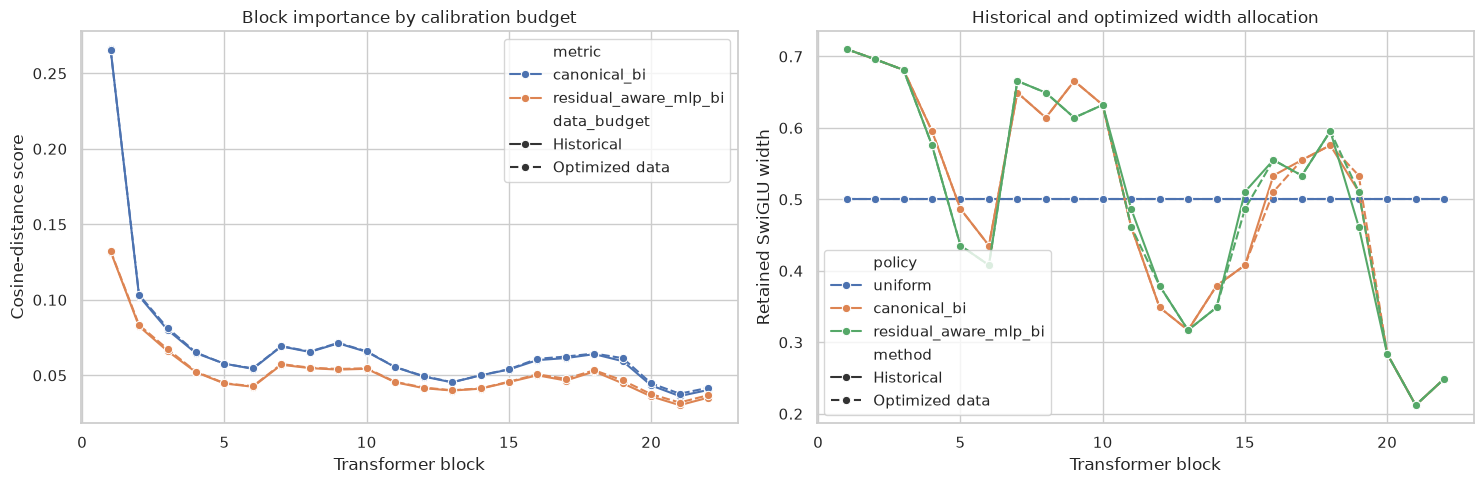

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
optimized_importance_plot_df = importance_comparison_df.melt(
    id_vars=['layer', 'data_budget'],
    value_vars=[
        'canonical_bi',
        'residual_aware_mlp_bi',
    ],
    var_name='metric',
    value_name='score',
)
sns.lineplot(
    data=optimized_importance_plot_df,
    x='layer',
    y='score',
    hue='metric',
    style='data_budget',
    marker='o',
    ax=axes[0],
)
axes[0].set_title('Block importance by calibration budget')
axes[0].set_xlabel('Transformer block')
axes[0].set_ylabel('Cosine-distance score')
sns.lineplot(
    data=allocation_comparison_df,
    x='layer',
    y='replacement_width_ratio',
    hue='policy',
    style='method',
    marker='o',
    ax=axes[1],
)
axes[1].set_title('Historical and optimized width allocation')
axes[1].set_xlabel('Transformer block')
axes[1].set_ylabel('Retained SwiGLU width')
fig.tight_layout()
plt.show()

new calibration data + random init

In [43]:
optimized_fitted_operators = {
    methodology: {policy: {} for policy in OPTIMIZED_POLICIES}
    for methodology in OPTIMIZED_METHOD_INITIALIZATIONS
}
optimized_layer_groups = [
    OPTIMIZED_ELIGIBLE_LAYERS[start:(
        start + OPTIMIZED_CAPTURE_GROUP_SIZE
    )]
    for start in range(
        0,
        len(OPTIMIZED_ELIGIBLE_LAYERS),
        OPTIMIZED_CAPTURE_GROUP_SIZE,
    )
]
if RUN_OPTIMIZED_SWIGLU:
    print(f'Activation storage dtype: {optimized_model_dtype}')
    print(f'Capture groups: {optimized_layer_groups}')

Activation storage dtype: torch.bfloat16
Capture groups: [(1, 2, 3, 4, 5, 6), (7, 8, 9, 10, 11, 12), (13, 14, 15, 16, 17, 18), (19, 20, 21, 22)]


In [44]:
if RUN_OPTIMIZED_SWIGLU:
    optimized_random_fitting_rows = []
    optimized_random_history_rows = []
    random_training_config = optimized_training_configs[
        'new_data_random'
    ]
    for group_index, layer_group in enumerate(
        optimized_layer_groups, start=1
    ):
        print(
            f'Capturing random-fit group {group_index}/'
            f'{len(optimized_layer_groups)} | {layer_group}'
        )
        group_paths = [
            optimized_blocks_by_layer[layer].path
            for layer in layer_group
        ]
        training_pairs_by_path = collect_modules_io(
            optimized_model,
            group_paths,
            optimized_loaders.calibration,
            optimized_data_config.num_calibration_batches,
            optimized_device,
            storage_device=(
                optimized_capture_config.storage_device
            ),
            storage_dtype=optimized_model_dtype,
        )
        validation_pairs_by_path = collect_modules_io(
            optimized_model,
            group_paths,
            optimized_loaders.operator_validation,
            (
                optimized_data_config
                .num_operator_validation_batches
            ),
            optimized_device,
            storage_device=(
                optimized_capture_config.storage_device
            ),
            storage_dtype=optimized_model_dtype,
        )
        report_memory(
            f'After random capture group {group_index}'
        )
        group_allocation_df = optimized_allocation_df[
            optimized_allocation_df['layer'].isin(layer_group)
        ]

        for policy, policy_allocation in group_allocation_df.groupby(
            'policy', sort=False
        ):
            print(f'Fitting random initialization | {policy}')
            for allocation in policy_allocation.itertuples(
                index=False
            ):
                layer = int(allocation.layer)
                block = optimized_blocks_by_layer[layer]
                training_pairs = training_pairs_by_path[block.path]
                validation_pairs = validation_pairs_by_path[block.path]
                torch.manual_seed(OPTIMIZED_SEED + layer)
                module = GatedMLPReplacement(
                    training_pairs.hidden_size,
                    int(allocation.replacement_width),
                ).to(optimized_device)
                initial_metrics = evaluate_operator(
                    module,
                    validation_pairs,
                    optimized_device,
                    random_training_config.batch_size,
                )
                fit = fit_operator(
                    module,
                    training_pairs,
                    validation_pairs,
                    random_training_config,
                    optimized_device,
                )
                metrics = evaluate_operator(
                    fit.module,
                    validation_pairs,
                    optimized_device,
                    random_training_config.batch_size,
                )
                optimized_fitted_operators[
                    'new_data_random'
                ][policy][layer] = fit.module.to(
                    device='cpu',
                    dtype=optimized_model_dtype,
                )
                optimized_random_fitting_rows.append({
                    'methodology': 'new_data_random',
                    'initialization': 'random_weights',
                    'policy': policy,
                    'layer': layer,
                    'replacement_width': int(
                        allocation.replacement_width
                    ),
                    'replacement_width_ratio': (
                        allocation.replacement_width_ratio
                    ),
                    'replacement_parameters': (
                        allocation.replacement_parameters
                    ),
                    'initial_local_mse': initial_metrics.mse,
                    'initial_local_relative_mse': (
                        initial_metrics.relative_mse
                    ),
                    'initial_local_cosine': (
                        initial_metrics.cosine_similarity
                    ),
                    'best_epoch': fit.best_epoch,
                    'local_mse': metrics.mse,
                    'local_relative_mse': metrics.relative_mse,
                    'local_cosine': metrics.cosine_similarity,
                    'nmse_improvement': (
                        initial_metrics.relative_mse
                        - metrics.relative_mse
                    ),
                })
                for epoch in fit.history:
                    optimized_random_history_rows.append({
                        'methodology': 'new_data_random',
                        'policy': policy,
                        'layer': layer,
                        'epoch': epoch.epoch,
                        'train_mse': epoch.train_mse,
                        'validation_mse': epoch.validation_mse,
                        'learning_rate': epoch.learning_rate,
                    })

        module = fit = metrics = initial_metrics = None
        training_pairs = validation_pairs = None
        training_pairs_by_path.clear()
        validation_pairs_by_path.clear()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        report_memory(
            f'After random-fit group {group_index}'
        )

    optimized_random_fitting_df = pd.DataFrame(
        optimized_random_fitting_rows
    )
    optimized_random_history_df = pd.DataFrame(
        optimized_random_history_rows
    )
    report_memory('After random fitting')
else:
    saved_fitting = pd.DataFrame(
        optimized_swiglu_artifact['results']['operator_fitting']
    )
    saved_history = pd.DataFrame(
        optimized_swiglu_artifact['results'][
            'operator_training_history'
        ]
    )
    optimized_random_fitting_df = saved_fitting.query(
        "methodology == 'new_data_random'"
    ).reset_index(drop=True)
    optimized_random_history_df = saved_history.query(
        "methodology == 'new_data_random'"
    ).reset_index(drop=True)

Capturing random-fit group 1/4 | (1, 2, 3, 4, 5, 6)
After random capture group 1: RAM 10.62 GiB, peak 10.62 GiB
Fitting random initialization | uniform
Fitting random initialization | canonical_bi
Fitting random initialization | residual_aware_mlp_bi
After random-fit group 1: RAM 6.13 GiB, peak 10.63 GiB
Capturing random-fit group 2/4 | (7, 8, 9, 10, 11, 12)
After random capture group 2: RAM 11.36 GiB, peak 11.70 GiB
Fitting random initialization | uniform
Fitting random initialization | canonical_bi
Fitting random initialization | residual_aware_mlp_bi
After random-fit group 2: RAM 6.86 GiB, peak 11.70 GiB
Capturing random-fit group 3/4 | (13, 14, 15, 16, 17, 18)
After random capture group 3: RAM 12.40 GiB, peak 12.63 GiB
Fitting random initialization | uniform
Fitting random initialization | canonical_bi
Fitting random initialization | residual_aware_mlp_bi
After random-fit group 3: RAM 7.90 GiB, peak 12.63 GiB
Capturing random-fit group 4/4 | (19, 20, 21, 22)
After random capture gr

new calibration + teacher init

In [45]:
if RUN_OPTIMIZED_SWIGLU:
    optimized_teacher_neuron_rankings = {}
    optimized_teacher_importance_rows = []
    teacher_training_config = optimized_training_configs[
        'complete_method'
    ]
else:
    optimized_teacher_neuron_rankings = None
    optimized_teacher_importance_df = pd.DataFrame(
        optimized_swiglu_artifact['results'][
            'teacher_neuron_importance'
        ]
    )

In [46]:
if RUN_OPTIMIZED_SWIGLU:
    optimized_teacher_fitting_rows = []
    optimized_teacher_history_rows = []

    for group_index, layer_group in enumerate(
        optimized_layer_groups, start=1
    ):
        print(
            f'Capturing teacher-fit group {group_index}/'
            f'{len(optimized_layer_groups)} | {layer_group}'
        )
        group_paths = [
            optimized_blocks_by_layer[layer].path
            for layer in layer_group
        ]
        training_pairs_by_path = collect_modules_io(
            optimized_model,
            group_paths,
            optimized_loaders.calibration,
            optimized_data_config.num_calibration_batches,
            optimized_device,
            storage_device=(
                optimized_capture_config.storage_device
            ),
            storage_dtype=optimized_model_dtype,
        )
        validation_pairs_by_path = collect_modules_io(
            optimized_model,
            group_paths,
            optimized_loaders.operator_validation,
            (
                optimized_data_config
                .num_operator_validation_batches
            ),
            optimized_device,
            storage_device=(
                optimized_capture_config.storage_device
            ),
            storage_dtype=optimized_model_dtype,
        )
        report_memory(
            f'After teacher capture group {group_index}'
        )

        for layer in layer_group:
            print(f'Ranking teacher neurons | layer {layer}')
            block = optimized_blocks_by_layer[layer]
            training_pairs = training_pairs_by_path[block.path]
            importance_scores = swiglu_neuron_importance_scores(
                block.module,
                training_pairs.inputs,
                teacher_training_config.batch_size,
            )
            ranking = torch.argsort(
                importance_scores,
                descending=True,
                stable=True,
            )
            optimized_teacher_neuron_rankings[layer] = ranking
            optimized_teacher_importance_rows.append({
                'layer': layer,
                'minimum_score': float(
                    importance_scores.min().item()
                ),
                'median_score': float(
                    importance_scores.median().item()
                ),
                'maximum_score': float(
                    importance_scores.max().item()
                ),
            })

        group_allocation_df = optimized_allocation_df[
            optimized_allocation_df['layer'].isin(layer_group)
        ]
        for policy, policy_allocation in group_allocation_df.groupby(
            'policy', sort=False
        ):
            print(f'Fitting teacher initialization | {policy}')
            for allocation in policy_allocation.itertuples(
                index=False
            ):
                layer = int(allocation.layer)
                block = optimized_blocks_by_layer[layer]
                training_pairs = training_pairs_by_path[block.path]
                validation_pairs = validation_pairs_by_path[block.path]
                replacement_width = int(
                    allocation.replacement_width
                )
                selected_indices = (
                    optimized_teacher_neuron_rankings[layer][
                        :replacement_width
                    ].sort().values
                )
                module = GatedMLPReplacement(
                    training_pairs.hidden_size,
                    replacement_width,
                ).to(optimized_device)
                initialize_gated_mlp_from_teacher(
                    module,
                    block.module,
                    selected_indices,
                )
                initial_metrics = evaluate_operator(
                    module,
                    validation_pairs,
                    optimized_device,
                    teacher_training_config.batch_size,
                )
                fit = fit_operator(
                    module,
                    training_pairs,
                    validation_pairs,
                    teacher_training_config,
                    optimized_device,
                )
                metrics = evaluate_operator(
                    fit.module,
                    validation_pairs,
                    optimized_device,
                    teacher_training_config.batch_size,
                )
                optimized_fitted_operators[
                    'complete_method'
                ][policy][layer] = fit.module.to(
                    device='cpu',
                    dtype=optimized_model_dtype,
                )
                optimized_teacher_fitting_rows.append({
                    'methodology': 'complete_method',
                    'initialization': (
                        'importance_teacher_subset'
                    ),
                    'policy': policy,
                    'layer': layer,
                    'replacement_width': replacement_width,
                    'replacement_width_ratio': (
                        allocation.replacement_width_ratio
                    ),
                    'replacement_parameters': (
                        allocation.replacement_parameters
                    ),
                    'initial_local_mse': initial_metrics.mse,
                    'initial_local_relative_mse': (
                        initial_metrics.relative_mse
                    ),
                    'initial_local_cosine': (
                        initial_metrics.cosine_similarity
                    ),
                    'best_epoch': fit.best_epoch,
                    'local_mse': metrics.mse,
                    'local_relative_mse': metrics.relative_mse,
                    'local_cosine': metrics.cosine_similarity,
                    'nmse_improvement': (
                        initial_metrics.relative_mse
                        - metrics.relative_mse
                    ),
                })
                for epoch in fit.history:
                    optimized_teacher_history_rows.append({
                        'methodology': 'complete_method',
                        'policy': policy,
                        'layer': layer,
                        'epoch': epoch.epoch,
                        'train_mse': epoch.train_mse,
                        'validation_mse': epoch.validation_mse,
                        'learning_rate': epoch.learning_rate,
                    })

        module = fit = metrics = initial_metrics = None
        training_pairs = validation_pairs = None
        importance_scores = selected_indices = None
        training_pairs_by_path.clear()
        validation_pairs_by_path.clear()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        report_memory(
            f'After teacher-fit group {group_index}'
        )

    optimized_teacher_importance_df = pd.DataFrame(
        optimized_teacher_importance_rows
    )
    optimized_teacher_fitting_df = pd.DataFrame(
        optimized_teacher_fitting_rows
    )
    optimized_teacher_history_df = pd.DataFrame(
        optimized_teacher_history_rows
    )
    report_memory('After teacher fitting and activation release')
else:
    optimized_teacher_fitting_df = saved_fitting.query(
        "methodology == 'complete_method'"
    ).reset_index(drop=True)
    optimized_teacher_history_df = saved_history.query(
        "methodology == 'complete_method'"
    ).reset_index(drop=True)

Capturing teacher-fit group 1/4 | (1, 2, 3, 4, 5, 6)
After teacher capture group 1: RAM 10.63 GiB, peak 13.86 GiB
Ranking teacher neurons | layer 1
Ranking teacher neurons | layer 2
Ranking teacher neurons | layer 3
Ranking teacher neurons | layer 4
Ranking teacher neurons | layer 5
Ranking teacher neurons | layer 6
Fitting teacher initialization | uniform
Fitting teacher initialization | canonical_bi
Fitting teacher initialization | residual_aware_mlp_bi
After teacher-fit group 1: RAM 6.24 GiB, peak 13.86 GiB
Capturing teacher-fit group 2/4 | (7, 8, 9, 10, 11, 12)
After teacher capture group 2: RAM 13.29 GiB, peak 14.87 GiB
Ranking teacher neurons | layer 7
Ranking teacher neurons | layer 8
Ranking teacher neurons | layer 9
Ranking teacher neurons | layer 10
Ranking teacher neurons | layer 11
Ranking teacher neurons | layer 12
Fitting teacher initialization | uniform
Fitting teacher initialization | canonical_bi
Fitting teacher initialization | residual_aware_mlp_bi
After teacher-fit 

block-level reporting

In [47]:
if RUN_OPTIMIZED_SWIGLU:
    optimized_operator_fitting_df = pd.concat(
        [
            optimized_random_fitting_df,
            optimized_teacher_fitting_df,
        ],
        ignore_index=True,
    )
    optimized_operator_history_df = pd.concat(
        [
            optimized_random_history_df,
            optimized_teacher_history_df,
        ],
        ignore_index=True,
    )
else:
    optimized_operator_fitting_df = saved_fitting
    optimized_operator_history_df = saved_history

SWIGLU_METHOD_LABELS = {
    'historical_random': 'Historical',
    'new_data_random': 'New data only',
    'complete_method': 'Complete method',
}
SWIGLU_METHOD_ORDER = list(SWIGLU_METHOD_LABELS.values())
historical_operator_fitting_df = pd.DataFrame(
    historical_swiglu_artifact['results']['operator_fitting']
).assign(
    methodology='historical_random',
    initialization='random_weights',
    initial_local_mse=float('nan'),
    initial_local_relative_mse=float('nan'),
    initial_local_cosine=float('nan'),
    nmse_improvement=float('nan'),
)
block_fitting_comparison_df = pd.concat(
    [
        historical_operator_fitting_df,
        optimized_operator_fitting_df,
    ],
    ignore_index=True,
)
block_fitting_comparison_df['method'] = (
    block_fitting_comparison_df['methodology'].map(
        SWIGLU_METHOD_LABELS
    )
)
block_fitting_summary_df = (
    block_fitting_comparison_df
    .groupby(
        ['methodology', 'method', 'policy'],
        sort=False,
        as_index=False,
    )
    .agg(
        fitted_blocks=('layer', 'count'),
        mean_width_ratio=('replacement_width_ratio', 'mean'),
        mean_initial_nmse=(
            'initial_local_relative_mse', 'mean'
        ),
        mean_fitted_nmse=('local_relative_mse', 'mean'),
        worst_fitted_nmse=('local_relative_mse', 'max'),
        mean_fitted_cosine=('local_cosine', 'mean'),
        mean_best_epoch=('best_epoch', 'mean'),
    )
)

In [48]:
display(
    block_fitting_summary_df[[
        'method',
        'policy',
        'fitted_blocks',
        'mean_width_ratio',
        'mean_initial_nmse',
        'mean_fitted_nmse',
        'worst_fitted_nmse',
        'mean_fitted_cosine',
        'mean_best_epoch',
    ]].style.format({
        'mean_width_ratio': '{:.3f}',
        'mean_initial_nmse': '{:.5f}',
        'mean_fitted_nmse': '{:.5f}',
        'worst_fitted_nmse': '{:.5f}',
        'mean_fitted_cosine': '{:.5f}',
        'mean_best_epoch': '{:.1f}',
    }, na_rep='not recorded')
)

,method,policy,fitted_blocks,mean_width_ratio,mean_initial_nmse,mean_fitted_nmse,worst_fitted_nmse,mean_fitted_cosine,mean_best_epoch
0,Historical,uniform,22,0.500,not recorded,0.55167,0.74297,0.58215,48.2
1,Historical,canonical_bi,22,0.500,not recorded,0.55344,0.74434,0.58247,49.0
2,Historical,residual_aware_mlp_bi,22,0.500,not recorded,0.55341,0.74851,0.58285,48.6
3,New data only,uniform,22,0.500,1.00000,0.39852,0.58534,0.72133,34.6
4,New data only,canonical_bi,22,0.500,1.00000,0.40102,0.58660,0.71981,36.8
5,New data only,residual_aware_mlp_bi,22,0.500,1.00000,0.40126,0.59427,0.71972,36.5
6,Complete method,uniform,22,0.500,0.23742,0.17315,0.26525,0.89850,3.7
7,Complete method,canonical_bi,22,0.500,0.24960,0.18298,0.42315,0.89318,4.0
8,Complete method,residual_aware_mlp_bi,22,0.500,0.25011,0.18390,0.42315,0.89287,3.9


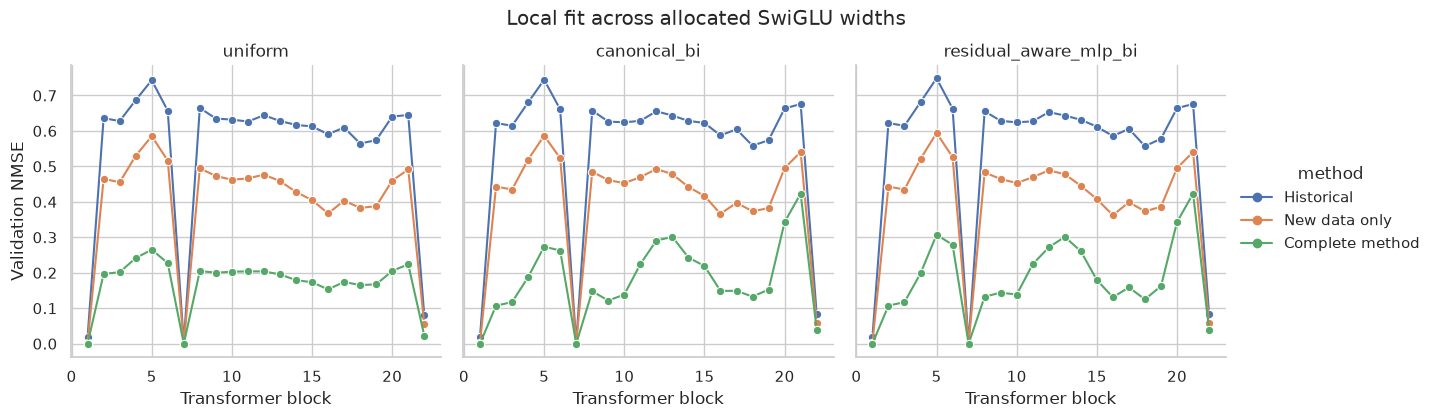

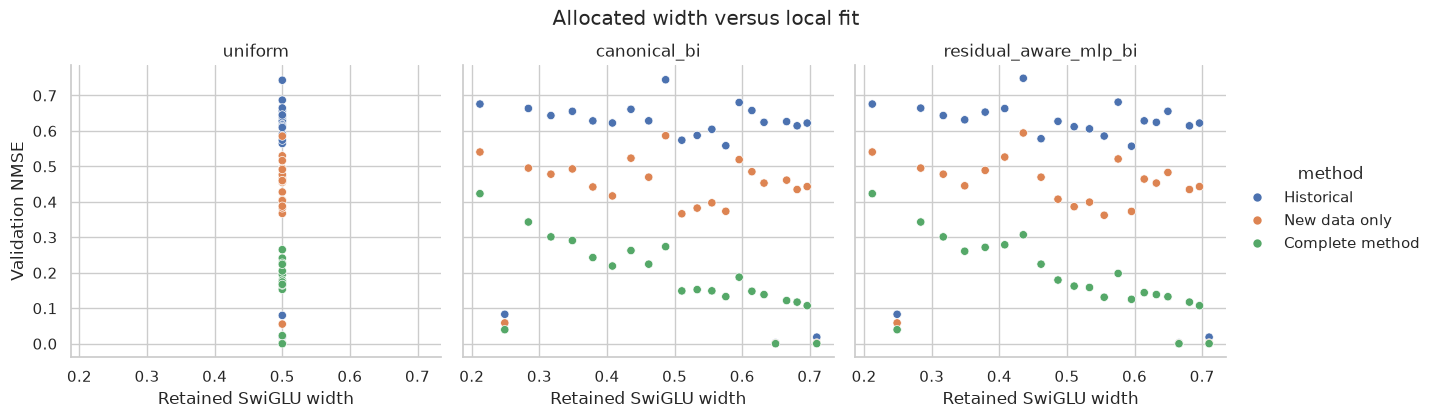

In [49]:
block_fit_plot = sns.relplot(
    data=block_fitting_comparison_df,
    x='layer',
    y='local_relative_mse',
    hue='method',
    hue_order=SWIGLU_METHOD_ORDER,
    col='policy',
    kind='line',
    marker='o',
    height=4,
    aspect=1.05,
)
block_fit_plot.set_axis_labels(
    'Transformer block',
    'Validation NMSE',
)
block_fit_plot.set_titles('{col_name}')
block_fit_plot.figure.suptitle(
    'Local fit across allocated SwiGLU widths',
    y=1.04,
)
plt.show()

width_fit_plot = sns.relplot(
    data=block_fitting_comparison_df,
    x='replacement_width_ratio',
    y='local_relative_mse',
    hue='method',
    hue_order=SWIGLU_METHOD_ORDER,
    col='policy',
    kind='scatter',
    height=4,
    aspect=1.05,
)
width_fit_plot.set_axis_labels(
    'Retained SwiGLU width',
    'Validation NMSE',
)
width_fit_plot.set_titles('{col_name}')
width_fit_plot.figure.suptitle(
    'Allocated width versus local fit',
    y=1.04,
)
plt.show()

model-level reporting

In [50]:
if RUN_OPTIMIZED_SWIGLU:
    report_memory('Before recovery caches')
    optimized_validation_teacher_cache = cache_teacher_logits(
        optimized_model,
        optimized_loaders.model_validation,
        optimized_data_config.num_model_validation_batches,
        optimized_device,
        optimized_recovery_config.cache_dtype,
    )
    optimized_recovery_teacher_cache = cache_teacher_logits(
        optimized_model,
        optimized_loaders.recovery,
        optimized_data_config.num_recovery_batches,
        optimized_device,
        optimized_recovery_config.cache_dtype,
    )
    optimized_recovery_validation_cache = cache_teacher_logits(
        optimized_model,
        optimized_loaders.recovery_validation,
        optimized_data_config.num_recovery_validation_batches,
        optimized_device,
        optimized_recovery_config.cache_dtype,
    )
    report_memory('After recovery caches')
    optimized_model_evaluation_rows = []
    optimized_recovery_rows = []

    for methodology, methods in (
        optimized_fitted_operators.items()
    ):
        for policy in OPTIMIZED_POLICIES:
            print(f'Evaluating {methodology} | {policy}')
            replacements = {
                layer: deepcopy(methods[policy][layer])
                for layer in OPTIMIZED_ELIGIBLE_LAYERS
            }
            policy_allocation = optimized_allocation_df.query(
                'policy == @policy'
            )
            realized_mlp_sparsity = (
                1
                - policy_allocation[
                    'replacement_parameters'
                ].sum()
                / policy_allocation['original_parameters'].sum()
            )
            with temporary_replacements(
                optimized_model, replacements
            ) as manifest:
                target_paths = [
                    record.path for record in manifest.records
                ]
                footprint = parameter_footprint(optimized_model)
                pre_metrics = evaluate_language_model(
                    optimized_model,
                    optimized_loaders.model_validation,
                    optimized_device,
                    (
                        optimized_data_config
                        .num_model_validation_batches
                    ),
                )
                pre_kl = mean_cache_loss(
                    optimized_model,
                    optimized_validation_teacher_cache,
                    optimized_recovery_config.temperature,
                    optimized_device,
                )
                optimized_model_evaluation_rows.append({
                    'methodology': methodology,
                    'policy': policy,
                    'phase': 'pre_recovery',
                    'parameters': footprint.parameters,
                    'realized_mlp_sparsity': (
                        realized_mlp_sparsity
                    ),
                    'model_sparsity': (
                        1
                        - footprint.parameters
                        / optimized_dense_footprint.parameters
                    ),
                    'theoretical_weight_bytes': (
                        footprint.theoretical_weight_bytes
                    ),
                    'teacher_kl': pre_kl,
                    'loss': pre_metrics.loss,
                    'loss_delta': (
                        pre_metrics.loss
                        - optimized_dense_metrics.loss
                    ),
                    'perplexity': pre_metrics.perplexity,
                    'perplexity_delta': (
                        pre_metrics.perplexity
                        - optimized_dense_metrics.perplexity
                    ),
                })

                recovery = recover_replacements(
                    optimized_model,
                    optimized_recovery_teacher_cache,
                    optimized_recovery_validation_cache,
                    target_paths,
                    optimized_recovery_config,
                    optimized_device,
                )
                post_metrics = evaluate_language_model(
                    optimized_model,
                    optimized_loaders.model_validation,
                    optimized_device,
                    (
                        optimized_data_config
                        .num_model_validation_batches
                    ),
                )
                post_kl = mean_cache_loss(
                    optimized_model,
                    optimized_validation_teacher_cache,
                    optimized_recovery_config.temperature,
                    optimized_device,
                )
                optimized_model_evaluation_rows.append({
                    'methodology': methodology,
                    'policy': policy,
                    'phase': 'post_recovery',
                    'parameters': footprint.parameters,
                    'realized_mlp_sparsity': (
                        realized_mlp_sparsity
                    ),
                    'model_sparsity': (
                        1
                        - footprint.parameters
                        / optimized_dense_footprint.parameters
                    ),
                    'theoretical_weight_bytes': (
                        footprint.theoretical_weight_bytes
                    ),
                    'teacher_kl': post_kl,
                    'loss': post_metrics.loss,
                    'loss_delta': (
                        post_metrics.loss
                        - optimized_dense_metrics.loss
                    ),
                    'perplexity': post_metrics.perplexity,
                    'perplexity_delta': (
                        post_metrics.perplexity
                        - optimized_dense_metrics.perplexity
                    ),
                })
                for epoch in recovery.history:
                    optimized_recovery_rows.append({
                        'methodology': methodology,
                        'policy': policy,
                        'epoch': epoch.epoch,
                        'train_kl': epoch.train_kl,
                        'validation_kl': epoch.validation_kl,
                        'best_epoch': recovery.best_epoch,
                    })

            for replacement in replacements.values():
                replacement.to('cpu')
            del replacements, replacement
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            report_memory(f'After recovery | {methodology} | {policy}')

    del optimized_validation_teacher_cache
    del optimized_recovery_teacher_cache
    del optimized_recovery_validation_cache
    report_memory('After recovery cache release')
    optimized_model_evaluation_df = pd.DataFrame(
        optimized_model_evaluation_rows
    )
    optimized_recovery_history_df = pd.DataFrame(
        optimized_recovery_rows
    )
else:
    optimized_model_evaluation_df = pd.DataFrame(
        optimized_swiglu_artifact['results']['model_evaluation']
    )
    optimized_recovery_history_df = pd.DataFrame(
        optimized_swiglu_artifact['results']['recovery_history']
    )

Before recovery caches: RAM 8.79 GiB, peak 15.80 GiB
After recovery caches: RAM 10.78 GiB, peak 15.80 GiB
Evaluating new_data_random | uniform
After recovery | new_data_random | uniform: RAM 10.92 GiB, peak 15.80 GiB
Evaluating new_data_random | canonical_bi
After recovery | new_data_random | canonical_bi: RAM 11.74 GiB, peak 15.80 GiB
Evaluating new_data_random | residual_aware_mlp_bi
After recovery | new_data_random | residual_aware_mlp_bi: RAM 11.76 GiB, peak 15.80 GiB
Evaluating complete_method | uniform
After recovery | complete_method | uniform: RAM 11.79 GiB, peak 15.80 GiB
Evaluating complete_method | canonical_bi
After recovery | complete_method | canonical_bi: RAM 11.80 GiB, peak 15.80 GiB
Evaluating complete_method | residual_aware_mlp_bi
After recovery | complete_method | residual_aware_mlp_bi: RAM 11.76 GiB, peak 15.80 GiB
After recovery cache release: RAM 10.81 GiB, peak 15.80 GiB


In [51]:
historical_model_evaluation_df = pd.DataFrame(
    historical_swiglu_artifact['results']['model_evaluation']
).assign(methodology='historical_random')
model_evaluation_comparison_df = pd.concat(
    [
        historical_model_evaluation_df,
        optimized_model_evaluation_df,
    ],
    ignore_index=True,
)
model_evaluation_comparison_df['method'] = (
    model_evaluation_comparison_df['methodology'].map(
        SWIGLU_METHOD_LABELS
    )
)
model_comparison_table = model_evaluation_comparison_df[[
    'method',
    'policy',
    'phase',
    'model_sparsity',
    'loss',
    'perplexity',
    'teacher_kl',
]].copy()
display(
    model_comparison_table.style.format({
        'model_sparsity': '{:.3%}',
        'loss': '{:.5f}',
        'perplexity': '{:.5f}',
        'teacher_kl': '{:.6f}',
    })
)

,method,policy,phase,model_sparsity,loss,perplexity,teacher_kl
0,Historical,uniform,pre_recovery,32.351%,24.46741,42272716172.70892,21.954329
1,Historical,uniform,post_recovery,32.351%,10.73690,46023.13983,8.083099
2,Historical,canonical_bi,pre_recovery,32.351%,24.09821,29222529492.99660,21.573125
3,Historical,canonical_bi,post_recovery,32.351%,10.94378,56600.91632,8.306232
4,Historical,residual_aware_mlp_bi,pre_recovery,32.351%,23.77179,21084193441.17403,21.248151
5,Historical,residual_aware_mlp_bi,post_recovery,32.351%,13.74622,933053.16619,11.065767
6,New data only,uniform,pre_recovery,32.351%,5.69669,297.88095,2.913910
7,New data only,uniform,post_recovery,32.351%,5.17319,176.47727,2.373203
8,New data only,canonical_bi,pre_recovery,32.351%,5.67986,292.90932,2.881664
9,New data only,canonical_bi,post_recovery,32.351%,5.25902,192.29256,2.450555


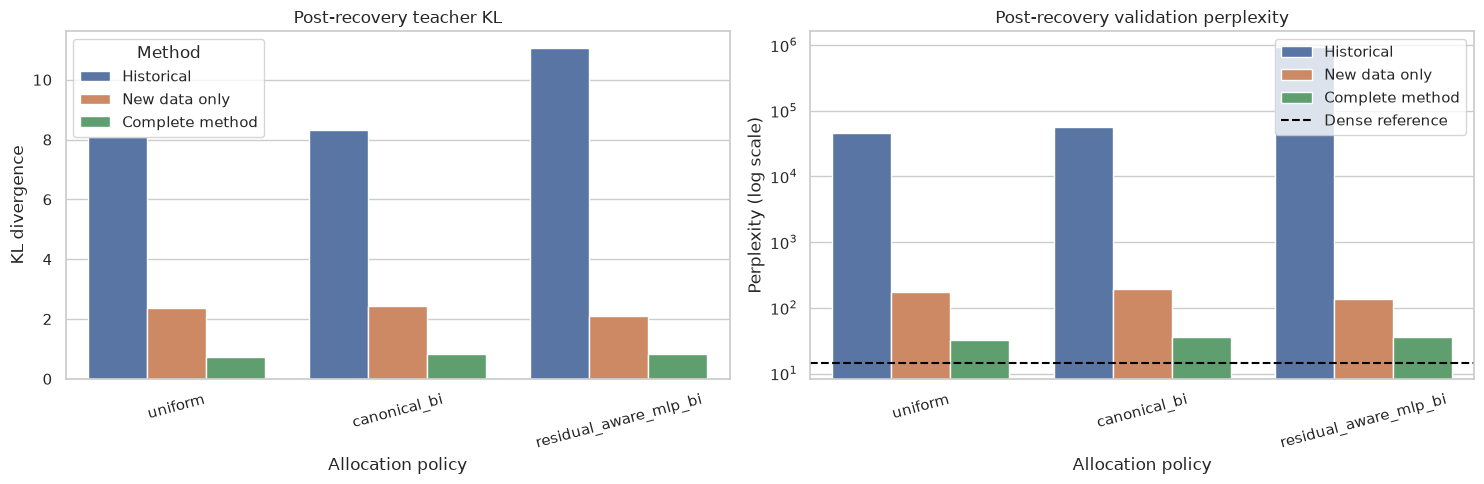

In [52]:
post_recovery_model_df = model_evaluation_comparison_df.query(
    "phase == 'post_recovery'"
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=post_recovery_model_df,
    x='policy',
    y='teacher_kl',
    hue='method',
    hue_order=SWIGLU_METHOD_ORDER,
    ax=axes[0],
)
axes[0].set_title('Post-recovery teacher KL')
axes[0].set_xlabel('Allocation policy')
axes[0].set_ylabel('KL divergence')
axes[0].tick_params(axis='x', rotation=15)
sns.barplot(
    data=post_recovery_model_df,
    x='policy',
    y='perplexity',
    hue='method',
    hue_order=SWIGLU_METHOD_ORDER,
    ax=axes[1],
)
dense_reference_perplexity = float(
    historical_swiglu_artifact['results'][
        'dense_reference'
    ][0]['perplexity']
)
axes[1].axhline(
    dense_reference_perplexity,
    color='black',
    linestyle='--',
    label='Dense reference',
)
axes[1].set_yscale('log')
axes[1].set_title('Post-recovery validation perplexity')
axes[1].set_xlabel('Allocation policy')
axes[1].set_ylabel('Perplexity (log scale)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
if axes[0].legend_ is not None:
    axes[0].legend(title='Method')
fig.tight_layout()
plt.show()

artifact

In [53]:
if RUN_OPTIMIZED_SWIGLU:
    optimized_calibration_pairs = (
        OPTIMIZED_CALIBRATION_BATCHES
        * optimized_data_config.batch_size
        * optimized_data_config.sequence_length
    )
    optimized_swiglu_artifact = {
        'schema_version': OPTIMIZED_SWIGLU_SCHEMA_VERSION,
        'created_at_utc': datetime.now(
            timezone.utc
        ).isoformat(),
        'environment': environment_record(),
        'configuration': {
            'model': {
                **asdict(optimized_model_config),
                'resolved_revision': getattr(
                    optimized_model.config,
                    '_commit_hash',
                    None,
                ),
            },
            'data': asdict(optimized_data_config),
            'capture': {
                **asdict(optimized_capture_config),
                'storage_dtype': str(
                    optimized_model_dtype
                ).removeprefix('torch.'),
                'module_group_size': (
                    OPTIMIZED_CAPTURE_GROUP_SIZE
                ),
            },
            'operator_training': {
                methodology: asdict(config)
                for methodology, config
                in optimized_training_configs.items()
            },
            'recovery': {
                **asdict(optimized_recovery_config),
                'trainable_scope': 'replacement_only',
            },
            'methodologies': {
                'historical_random': {
                    'calibration_pairs': (
                        BASE_CALIBRATION_BATCHES
                        * optimized_data_config.batch_size
                        * optimized_data_config.sequence_length
                    ),
                    'initialization': 'random_weights',
                },
                'new_data_random': {
                    'calibration_pairs': (
                        optimized_calibration_pairs
                    ),
                    'initialization': 'random_weights',
                },
                'complete_method': {
                    'calibration_pairs': (
                        optimized_calibration_pairs
                    ),
                    'initialization': (
                        'importance_teacher_subset'
                    ),
                    'importance_metric': (
                        'rms_intermediate_activation_times_'
                        'down_projection_column_l2'
                    ),
                },
            },
            'historical_control': {
                'artifact_path': str(
                    HISTORICAL_SWIGLU_ARTIFACT_PATH
                ),
                'schema_version': (
                    historical_swiglu_artifact['schema_version']
                ),
            },
            'partition_order': list(
                optimized_partition_batches
            ),
            'target_mlp_sparsity': (
                OPTIMIZED_TARGET_MLP_SPARSITY
            ),
            'allocation_temperature': (
                OPTIMIZED_ALLOCATION_TEMPERATURE
            ),
            'allocation_policies': list(OPTIMIZED_POLICIES),
            'eligible_layers': list(
                OPTIMIZED_ELIGIBLE_LAYERS
            ),
            'protected_layers': list(
                OPTIMIZED_PROTECTED_LAYERS
            ),
        },
        'results': {
            'dense_reference': json.loads(
                optimized_dense_reference_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'importance': json.loads(
                optimized_importance_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'importance_comparison': json.loads(
                importance_comparison_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'allocation': json.loads(
                optimized_allocation_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'allocation_summary': json.loads(
                optimized_allocation_summary_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'allocation_comparison': json.loads(
                allocation_comparison_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'teacher_neuron_importance': json.loads(
                optimized_teacher_importance_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'teacher_neuron_rankings': {
                str(layer): ranking.tolist()
                for layer, ranking
                in optimized_teacher_neuron_rankings.items()
            },
            'operator_fitting': json.loads(
                optimized_operator_fitting_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'operator_training_history': json.loads(
                optimized_operator_history_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'block_fitting_comparison': json.loads(
                block_fitting_comparison_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'block_fitting_summary': json.loads(
                block_fitting_summary_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'model_evaluation': json.loads(
                optimized_model_evaluation_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'recovery_history': json.loads(
                optimized_recovery_history_df.to_json(
                    orient='records', double_precision=15
                )
            ),
            'model_evaluation_comparison': json.loads(
                model_evaluation_comparison_df.to_json(
                    orient='records', double_precision=15
                )
            ),
        },
    }
    OPTIMIZED_SWIGLU_ARTIFACT_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    OPTIMIZED_SWIGLU_ARTIFACT_PATH.write_text(
        json.dumps(
            optimized_swiglu_artifact,
            indent=2,
            allow_nan=False,
        ),
        encoding='utf-8',
    )
    print(
        f'Saved optimized SwiGLU artifact to '
        f'{OPTIMIZED_SWIGLU_ARTIFACT_PATH}'
    )
else:
    print(
        f'Loaded optimized SwiGLU artifact from '
        f'{OPTIMIZED_SWIGLU_ARTIFACT_PATH}'
    )

Saved optimized SwiGLU artifact to /home/sgulas/thesis/development/data/results/notebook-model-study/swiglu-compression-optimized.json


___

### Documentation

Setup

1. Imports and project path  
   Makes the optimized section self-contained and imports the fitting, recovery, initialization, evaluation, and data utilities.

2. Execution constants  
   Selects `run` or `load`, defines historical and optimized artifact paths, 384 calibration batches, methods, and allocation policies.

3. Artifact loading  
   Loads and validates the historical artifact. In `load` mode, it also loads the optimized artifact.

4. Configuration  
   Reconstructs the historical configuration, pins the original model revision, and creates random and teacher-initialized 64-epoch configurations.

5. Model and data  
   Loads the dense model and constructs 98,304 calibration pairs. Existing validation and recovery partitions remain unchanged; additional calibration data is appended afterward.

6. Dense reference  
   Measures the unchanged model’s footprint, loss, and perplexity and calculates the eligible MLP parameter budget.

Importance screening + width allocation

1. Importance computation  
   Calculates canonical BI and residual-aware MLP BI scores across all eligible blocks using the larger calibration set.

2. Width allocation  
   Converts each importance distribution into per-block SwiGLU widths while maintaining 50% total eligible-MLP sparsity. It also constructs the uniform allocation.

3. Allocation tables  
   Displays importance scores, allocation summaries, and exact retained width ratios.

4. Allocation plots  
   Compares historical versus optimized importance estimates and resulting block-width distributions.

New calibration data + random initialization

1. Activation capture  
   Captures the 98,304 training pairs and unchanged validation pairs for all eligible blocks. These pairs are shared with teacher initialization.

2. Random fitting  
   Fits every block for all three allocation policies from random weights and records initial metrics, fitted NMSE, cosine similarity, best epoch, and training history.

New calibration + teacher initialization

1. Teacher-neuron ranking  
   Calculates the activation-and-down-projection importance score for every teacher SwiGLU neuron and ranks them separately for every block.

2. Teacher-initialized fitting  
   Selects the top neurons matching each allocated width, copies their gate/up/down weights, evaluates the initialization, and then performs distillation.

Block-level reporting

1. Result preparation  
   Combines historical, larger-data random, and complete-method block results and calculates aggregate metrics per allocation policy.

2. Summary table  
   Reports mean width, initial NMSE, fitted NMSE, worst-block NMSE, cosine similarity, and fitting epoch.

3. Plots  
   Shows NMSE across model depth and the relationship between assigned width and achieved NMSE.

Model-level reporting

1. Model evaluation  
   Releases activation caches, creates recovery teacher caches, temporarily inserts each fitted operator set, and measures PPL and KL before and after recovery.

2. Comparison table  
   Compares all methodologies, allocation policies, and recovery phases.

3. Plots  
   Compares post-recovery teacher KL and perplexity, including the dense-model reference.

Artifact

Saves configuration, importance scores, allocations, neuron rankings, fitting histories, block results, model results, and historical comparisons to `swiglu-compression-optimized.json`.